# HerittageFNS — Bước 1: Trích Đặc Trưng Âm Thanh
## Âm nhạc Di sản Văn hóa Việt Nam

**Dataset:** `NTQAI/Vietnamese-Traditional-Music` — 10 thể loại, ~147,000 mẫu  
**Pipeline:** Trích đặc trưng → Biểu diễn → Phân cụm Fuzzy → Học luật mờ thần kinh

| Thể loại | Thể loại |
|---|---|
| Ca trù | Hát then |
| Cải lương | Hát xoan |
| Chầu văn | Nhã nhạc cung đình Huế |
| Chèo | Quan họ |
| Đờn ca tài tử | Tuồng |

## Bước 0: Cài đặt & Import

In [1]:
# Chạy lần đầu nếu chưa cài:
# !pip install librosa scikit-fuzzy datasets soundfile audioread

In [2]:
import os, warnings, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import librosa
import librosa.display

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import skfuzzy as fuzz
from skfuzzy import cmeans

from datasets import load_dataset
from huggingface_hub import hf_hub_download

warnings.filterwarnings('ignore')
Path('./data').mkdir(parents=True, exist_ok=True)

# Dark theme
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'text.color': '#e6edf3',
    'axes.labelcolor': '#e6edf3', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d', 'font.size': 11,
})

# 6 thể loại thực tế trong dataset NTQAI/Vietnamese-Traditional-Music
GENRE_COLORS = {
    'Cải lương': '#4ECDC4',
    'Quan họ':   '#FF8B94',
    'Chầu văn':  '#45B7D1',
    'Chèo':      '#96CEB4',
    'Ca trù':    '#FF6B6B',
    'Hát xẩm':   '#F0A500',
}

def get_color(label):
    lbl_str = str(label).strip()
    if lbl_str in GENRE_COLORS:
        return GENRE_COLORS[lbl_str]
    for k, v in GENRE_COLORS.items():
        if k.lower() in lbl_str.lower():
            return v
    colors = list(GENRE_COLORS.values())
    return colors[hash(lbl_str) % len(colors)]

print(f'librosa {librosa.__version__} | numpy {np.__version__} | Setup hoàn tất!')


C:\Users\ADMIN\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


librosa 1.0.0 | numpy 2.5.3 | Setup hoàn tất!


## Bước 1: Tải Dataset

In [3]:
# ============================================================
# TẢI DATASET - NTQAI/Vietnamese-Traditional-Music
# Dataset này PUBLIC, không cần HuggingFace token.
# Cột: 'audio' (str path), 'text' (str), 'label' (str)
# Sau khi cast_column('audio', Audio()), 'audio' sẽ là:
#   {'array': np.ndarray, 'sampling_rate': int, 'path': str}
# ============================================================

MAX_PER_GENRE = 300   # Số mẫu tối đa mỗi thể loại
SR_TARGET     = 16000  # Chuẩn 16 kHz (tương thích MERT / AudioMAE) # Sample rate chuẩn

print('Đang tải dataset NTQAI/Vietnamese-Traditional-Music...')
print('(Lần đầu có thể mất 1-3 phút để tải metadata)')

ds_raw = load_dataset(
    'NTQAI/Vietnamese-Traditional-Music',
    split='train',
    trust_remote_code=False,
)

print(f'Tải xong! Tổng: {len(ds_raw)} mẫu')
print(f'Cột: {ds_raw.column_names}')
print(f'Mẫu 0 - label: {ds_raw[0]["label"]}')


Đang tải dataset NTQAI/Vietnamese-Traditional-Music...
(Lần đầu có thể mất 1-3 phút để tải metadata)
Tải xong! Tổng: 147260 mẫu
Cột: ['audio', 'text', 'label']
Mẫu 0 - label: Cải lương


Tìm thấy 6 thể loại:
Cải lương    67400
Quan họ      38070
Chầu văn     17670
Chèo         14450
Ca trù        6380
Hát xẩm       3290


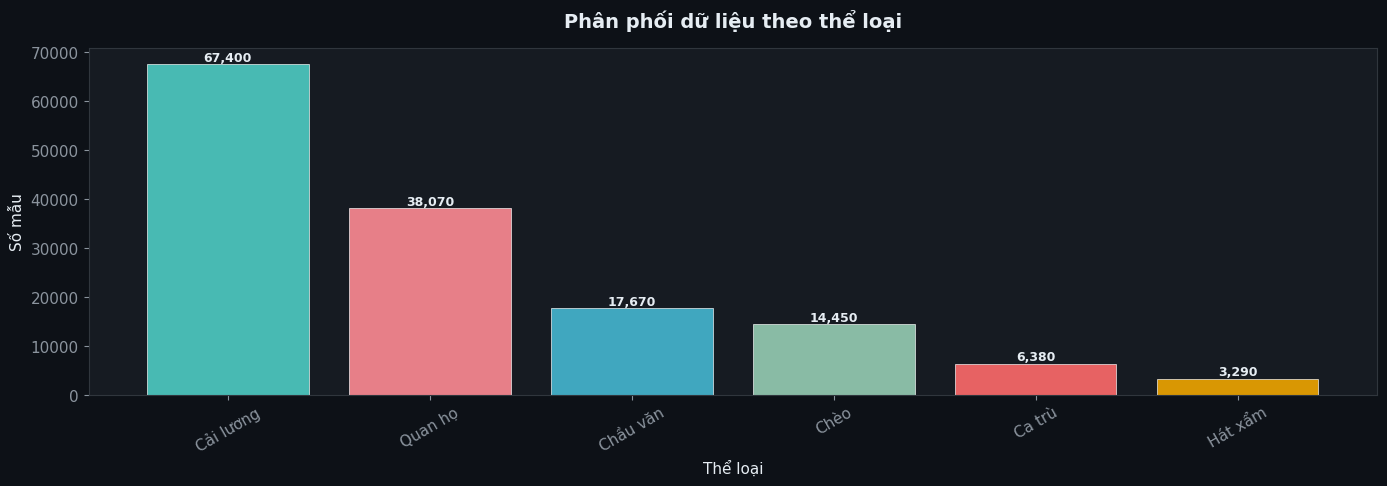

Saved: ./data/01_genre_distribution.png


In [4]:
# Phân phối theo thể loại
all_labels  = ds_raw['label']
label_counts = Counter(all_labels)
counts = pd.Series(label_counts).sort_values(ascending=False)
print(f'Tìm thấy {len(counts)} thể loại:')
print(counts.to_string())

# Biểu đồ
fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [get_color(g) for g in counts.index]
bars = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', lw=0.5, alpha=0.9)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Phân phối dữ liệu theo thể loại', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Thể loại'); ax.set_ylabel('Số mẫu')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('./data/01_genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./data/01_genre_distribution.png')

In [5]:
# Lấy mẫu cân bằng theo các thể loại
print(f'Chọn tối đa {MAX_PER_GENRE} mẫu/thể loại...')

balanced_indices = []
genre_index_map  = {}

for genre in counts.index:
    idx     = [i for i, lbl in enumerate(all_labels) if lbl == genre]
    sampled = idx[:MAX_PER_GENRE]
    balanced_indices.extend(sampled)
    genre_index_map[genre] = sampled
    print(f'  {genre:30s}: {len(sampled):4d} mẫu')

# Chọn các mẫu cân bằng
ds_balanced = ds_raw.select(balanced_indices)
LABEL_COL = 'label'
AUDIO_COL = 'audio'

print(f'\nTổng mẫu cân bằng: {len(ds_balanced)}')
print(f'Mẫu đầu tiên: label={ds_balanced[0][LABEL_COL]}, audio={ds_balanced[0][AUDIO_COL]}')


Chọn tối đa 300 mẫu/thể loại...
  Cải lương                     :  300 mẫu
  Quan họ                       :  300 mẫu
  Chầu văn                      :  300 mẫu
  Chèo                          :  300 mẫu
  Ca trù                        :  300 mẫu
  Hát xẩm                       :  300 mẫu

Tổng mẫu cân bằng: 1800
Mẫu đầu tiên: label=Cải lương, audio=cailuong/audio_16_008.wav


## Bước 2: Trích Xuất Đặc Trưng Âm Thanh

In [6]:
def get_audio(samp):
    """Lấy (array float32, sample_rate) từ 1 mẫu dataset."""
    raw = samp[AUDIO_COL]

    if isinstance(raw, dict) and 'array' in raw:
        arr = np.array(raw['array'], dtype=np.float32)
        sr  = int(raw.get('sampling_rate', SR_TARGET))
    elif isinstance(raw, dict) and 'bytes' in raw and raw['bytes']:
        import soundfile as sf, io
        arr, sr = sf.read(io.BytesIO(raw['bytes']))
        arr = arr.astype(np.float32)
    elif isinstance(raw, (list, np.ndarray)):
        arr = np.array(raw, dtype=np.float32)
        sr  = SR_TARGET
    elif isinstance(raw, bytes):
        import soundfile as sf, io
        arr, sr = sf.read(io.BytesIO(raw))
        arr = arr.astype(np.float32)
    elif isinstance(raw, str):
        # File âm thanh nằm trong thư mục audios/ trên HuggingFace Hub
        hf_path = raw if raw.startswith('audios/') else f'audios/{raw}'
        local = hf_hub_download(
            repo_id='NTQAI/Vietnamese-Traditional-Music',
            filename=hf_path,
            repo_type='dataset',
        )
        arr, sr = librosa.load(local, sr=SR_TARGET, mono=True)
    else:
        raise ValueError(f'Kiểu audio không rõ: {type(raw)}')

    # Normalize về [-1, 1] nếu cần
    mx = np.max(np.abs(arr))
    if mx > 1.0:
        arr = arr / mx
    return arr, sr


def extract_features(arr, sr, n_mfcc=40):
    """Trích xuất đặc trưng âm thanh từ 1 mẫu."""
    feats = {}

    # Đảm bảo mono + trim + cắt 30 giây giữa bài
    if arr.ndim > 1:
        arr = librosa.to_mono(arr.T)
    arr, _ = librosa.effects.trim(arr, top_db=20)
    # Cắt cửa sổ cố định 10 giây ở giữa bài (sau khi trim)
    # Giúp F0/Vibrato mang tính đặc trưng cục bộ cao và tăng tốc độ trích xuất gấp 3 lần
    TARGET_DURATION = 10  # giây
    max_len = int(TARGET_DURATION * sr)
    if len(arr) > max_len:
        mid = len(arr) // 2
        arr = arr[mid - max_len//2 : mid + max_len//2]
    if len(arr) == 0:
        return feats

    # 1. F0 / Pitch
    try:
        f0, voiced, _ = librosa.pyin(arr, sr=sr,
            fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
        f0v = f0[voiced] if voiced.any() else np.array([])
        feats['pitch_mean']   = float(np.nanmean(f0v))   if len(f0v) else 0.0
        feats['pitch_std']    = float(np.nanstd(f0v))    if len(f0v) else 0.0
        feats['pitch_range']  = float(np.nanmax(f0v) - np.nanmin(f0v)) if len(f0v) else 0.0
        feats['pitch_median'] = float(np.nanmedian(f0v)) if len(f0v) else 0.0
        feats['voiced_ratio'] = float(voiced.mean())
        feats['_f0'] = f0
    except Exception:
        feats.update({'pitch_mean':0,'pitch_std':0,'pitch_range':0,
                      'pitch_median':0,'voiced_ratio':0,'_f0':None})

    # 2. Tempo / Beat
    try:
        tempo, beats = librosa.beat.beat_track(y=arr, sr=sr)
        bt = librosa.frames_to_time(beats, sr=sr)
        feats['tempo']          = float(np.squeeze(tempo))
        feats['beat_count']     = len(beats)
        ioi = np.diff(bt)
        feats['beat_regularity'] = float(1 - np.std(ioi)/(np.mean(ioi)+1e-6)) if len(ioi)>1 else 0.0
    except Exception:
        feats.update({'tempo':0,'beat_count':0,'beat_regularity':0})

    # 3. Vibrato (bandpass F0 4-10 Hz)
    try:
        from scipy.signal import butter, filtfilt
        f0c = feats.get('_f0')
        if f0c is not None and len(f0c) > 30:
            fps = sr / 512
            vf0 = np.where(np.isnan(f0c), 0, f0c)
            idx_v = np.where(vf0 > 0)[0]
            if len(idx_v) > 10:
                f0i = np.interp(np.arange(len(vf0)), idx_v, vf0[idx_v])
                lo, hi = 4/(fps/2), min(10/(fps/2), 0.99)
                if lo < hi:
                    b, a = butter(2, [lo, hi], btype='band')
                    vib = filtfilt(b, a, f0i)
                    feats['vibrato_extent'] = float(np.std(vib))
                    feats['vibrato_energy'] = float(np.mean(vib**2))
                else:
                    feats.update({'vibrato_extent':0,'vibrato_energy':0})
            else:
                feats.update({'vibrato_extent':0,'vibrato_energy':0})
        else:
            feats.update({'vibrato_extent':0,'vibrato_energy':0})
    except Exception:
        feats.update({'vibrato_extent':0,'vibrato_energy':0})

    # 4. Energy / RMS
    try:
        rms = librosa.feature.rms(y=arr)[0]
        feats['energy_mean']   = float(np.mean(rms))
        feats['energy_std']    = float(np.std(rms))
        feats['dynamic_range'] = float(np.ptp(rms))
        feats['energy_skew']   = float(pd.Series(rms).skew())
    except Exception:
        feats.update({'energy_mean':0,'energy_std':0,'dynamic_range':0,'energy_skew':0})

    # 5. MFCC
    try:
        mfcc   = librosa.feature.mfcc(y=arr, sr=sr, n_mfcc=n_mfcc)
        dmfcc  = librosa.feature.delta(mfcc)
        d2mfcc = librosa.feature.delta(mfcc, order=2)
        for i in range(n_mfcc):
            feats[f'mfcc_{i+1:02d}_mean'] = float(np.mean(mfcc[i]))
            feats[f'mfcc_{i+1:02d}_std']  = float(np.std(mfcc[i]))
        for i in range(13):
            feats[f'dmfcc_{i+1:02d}_mean']  = float(np.mean(dmfcc[i]))
            feats[f'd2mfcc_{i+1:02d}_mean'] = float(np.mean(d2mfcc[i]))
        feats['_mfcc'] = mfcc
    except Exception:
        feats['_mfcc'] = None

    # 6. Chroma
    try:
        chroma = librosa.feature.chroma_stft(y=arr, sr=sr)
        NOTES  = ['C','Cs','D','Ds','E','F','Fs','G','Gs','A','As','B']
        for i, n in enumerate(NOTES):
            feats[f'chroma_{n}_mean'] = float(np.mean(chroma[i]))
            feats[f'chroma_{n}_std']  = float(np.std(chroma[i]))
        feats['chroma_std_overall'] = float(np.std(chroma))
        feats['_chroma'] = chroma
    except Exception:
        feats['_chroma'] = None

    # 7. Spectral
    try:
        sc  = librosa.feature.spectral_centroid(y=arr, sr=sr)[0]
        sb  = librosa.feature.spectral_bandwidth(y=arr, sr=sr)[0]
        sro = librosa.feature.spectral_rolloff(y=arr, sr=sr)[0]
        sct = librosa.feature.spectral_contrast(y=arr, sr=sr)
        sf_ = librosa.feature.spectral_flatness(y=arr)[0]
        feats.update({
            'spectral_centroid_mean': float(np.mean(sc)),
            'spectral_centroid_std':  float(np.std(sc)),
            'spectral_bandwidth_mean':float(np.mean(sb)),
            'spectral_rolloff_mean':  float(np.mean(sro)),
            'spectral_flatness_mean': float(np.mean(sf_)),
        })
        for i in range(sct.shape[0]):
            feats[f'spectral_contrast_{i+1}'] = float(np.mean(sct[i]))
    except Exception:
        pass

    # 8. ZCR
    try:
        zcr = librosa.feature.zero_crossing_rate(arr)[0]
        feats['zcr_mean'] = float(np.mean(zcr))
        feats['zcr_std']  = float(np.std(zcr))
    except Exception:
        pass

    # 9. Tonnetz
    try:
        tz = librosa.feature.tonnetz(y=arr, sr=sr)
        for i in range(6):
            feats[f'tonnetz_{i+1}'] = float(np.mean(tz[i]))
    except Exception:
        pass

    # 10. Mel spectrogram
    try:
        mel    = librosa.feature.melspectrogram(y=arr, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        feats['mel_mean'] = float(np.mean(mel_db))
        feats['mel_std']  = float(np.std(mel_db))
        feats['_mel']     = mel_db
    except Exception:
        feats['_mel'] = None

    feats['_audio'] = arr[:int(sr*10)]
    feats['_sr']    = sr
    return feats


PRIVATE = {'_f0','_mfcc','_chroma','_mel','_audio','_sr'}

def get_public(d):
    return {k: v for k, v in d.items()
            if k not in PRIVATE and isinstance(v, (int, float, np.floating)) and np.isfinite(v)}

print('Các hàm đã định nghĩa xong: get_audio(), extract_features(), get_public()')


Các hàm đã định nghĩa xong: get_audio(), extract_features(), get_public()


In [7]:
# Thử nghiệm với 1 mẫu
print('=== Thử nghiệm 1 mẫu ===')
s0    = ds_balanced[0]
arr0, sr0 = get_audio(s0)

print(f'Label  : {s0[LABEL_COL]}')
print(f'SR     : {sr0} Hz')
print(f'Dài    : {len(arr0)/sr0:.1f}s')
print(f'Shape  : {arr0.shape}')
print(f'Amp    : [{arr0.min():.3f}, {arr0.max():.3f}]')

f0 = extract_features(arr0, sr0)
pub = get_public(f0)
print(f'\nSố đặc trưng: {len(pub)}')
for k in ['pitch_mean','tempo','vibrato_extent','energy_mean',
          'mfcc_01_mean','spectral_centroid_mean']:
    if k in pub:
        print(f'  {k:35s}: {pub[k]:.4f}')
print('\nOK!')

=== Thử nghiệm 1 mẫu ===
Label  : Cải lương
SR     : 16000 Hz
Dài    : 45.0s
Shape  : (720000,)
Amp    : [-0.482, 0.438]

Số đặc trưng: 167
  pitch_mean                         : 169.0441
  tempo                              : 156.2500
  vibrato_extent                     : 5.1426
  energy_mean                        : 0.0484
  mfcc_01_mean                       : -277.6563
  spectral_centroid_mean             : 1079.2854

OK!


In [8]:
# ============================================================
# TRÍCH XUẤT TOÀN BỘ (có cache để không phải chạy lại)
# ============================================================
CACHE_FILE = Path('./data/features_cache.pkl')

if CACHE_FILE.exists():
    print('Tải từ cache...')
    with open(CACHE_FILE, 'rb') as f:
        results = pickle.load(f)
    print(f'Loaded {len(results)} mẫu từ cache!')
else:
    print(f'Trích xuất {len(ds_balanced)} mẫu (có thể mất 30-90 phút)...')
    results, errors = [], []

    for i, samp in enumerate(tqdm(ds_balanced, desc='Extracting')):
        try:
            arr, sr = get_audio(samp)
            feat    = extract_features(arr, sr)
            row     = get_public(feat)
            row['label']      = samp[LABEL_COL]
            row['sample_idx'] = i
            # Lưu thêm để visualize
            for pk in ['_f0','_mfcc','_mel','_chroma','_audio','_sr']:
                row[pk] = feat.get(pk)
            results.append(row)
        except Exception as e:
            errors.append((i, str(e)))

    print(f'Hoàn thành! {len(results)} OK, {len(errors)} lỗi')
    if errors:
        print('5 lỗi đầu:')
        for ii, msg in errors[:5]:
            print(f'  [{ii}] {msg[:100]}')
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(results, f)
    print(f'Lưu cache: {CACHE_FILE}')

df = pd.DataFrame([{k:v for k,v in r.items() if k not in PRIVATE} for r in results])
df.to_csv('./data/features_all.csv', index=False)
print(f'DataFrame: {df.shape[0]} mẫu × {df.shape[1]} cột')
df.head()

Trích xuất 1800 mẫu (có thể mất 30-90 phút)...


Extracting:  78%|███████▊  | 1411/1800 [1:12:23<20:54,  3.22s/it]'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 029e5ff7-8d69-4288-baec-bca3150c8203)')' thrown while requesting HEAD https://huggingface.co/datasets/NTQAI/Vietnamese-Traditional-Music/resolve/main/audios/ca_tru/audio_17_029.wav
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /datasets/NTQAI/Vietnamese-Traditional-Music/resolve/main/audios/ca_tru/audio_17_029.wav (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000023B0DF1FA10>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: bce69868-e38f-452d-b117-61c1177a3bb8)')' thrown while requesting HEAD https://huggingface.co/datasets/NTQAI/Vietnamese-Traditional-Music/resolve/main/audios/ca_tru/audio_17_029.wav
Retrying in 2s [Retry 2/5].
'(MaxRetry

Hoàn thành! 1800 OK, 0 lỗi
Lưu cache: data\features_cache.pkl
DataFrame: 1800 mẫu × 169 cột


,pitch_mean,pitch_std,pitch_range,pitch_median,voiced_ratio,tempo,beat_count,beat_regularity,vibrato_extent,vibrato_energy,...,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,mel_mean,mel_std,label,sample_idx
0,169.044068,46.396281,169.405799,180.251285,0.747604,156.250000,25,0.941075,5.142594,26.446273,...,0.105777,0.056288,0.068860,-0.010367,-0.013710,-0.004597,-47.927334,17.363058,Cải lương,0
1,180.408128,62.698757,243.572042,176.643034,0.677316,93.750000,15,0.949591,5.325498,28.360985,...,0.063683,0.014011,-0.015533,-0.048731,0.003920,0.005742,-45.176598,17.394558,Cải lương,1
2,246.084547,101.129062,433.259848,229.077674,0.824281,104.166667,13,0.940996,8.141602,66.288827,...,0.000254,0.048072,0.113782,0.045192,-0.004415,-0.027704,-46.422604,14.552546,Cải lương,2
3,185.614716,77.685938,405.795037,171.614350,0.904153,156.250000,24,0.930495,6.110566,37.339041,...,0.158012,0.085075,-0.139784,-0.083569,-0.056563,-0.053786,-54.981461,16.259699,Cải lương,3
4,325.230720,74.239084,340.252812,323.964753,0.718850,93.750000,11,0.927536,9.790573,95.860210,...,-0.089148,0.016988,-0.041507,-0.038129,-0.004009,-0.012314,-46.790478,14.785275,Cải lương,4


## Bước 3: Biểu Diễn Đặc Trưng Âm Thanh (Visualization)


=== Cải lương ===


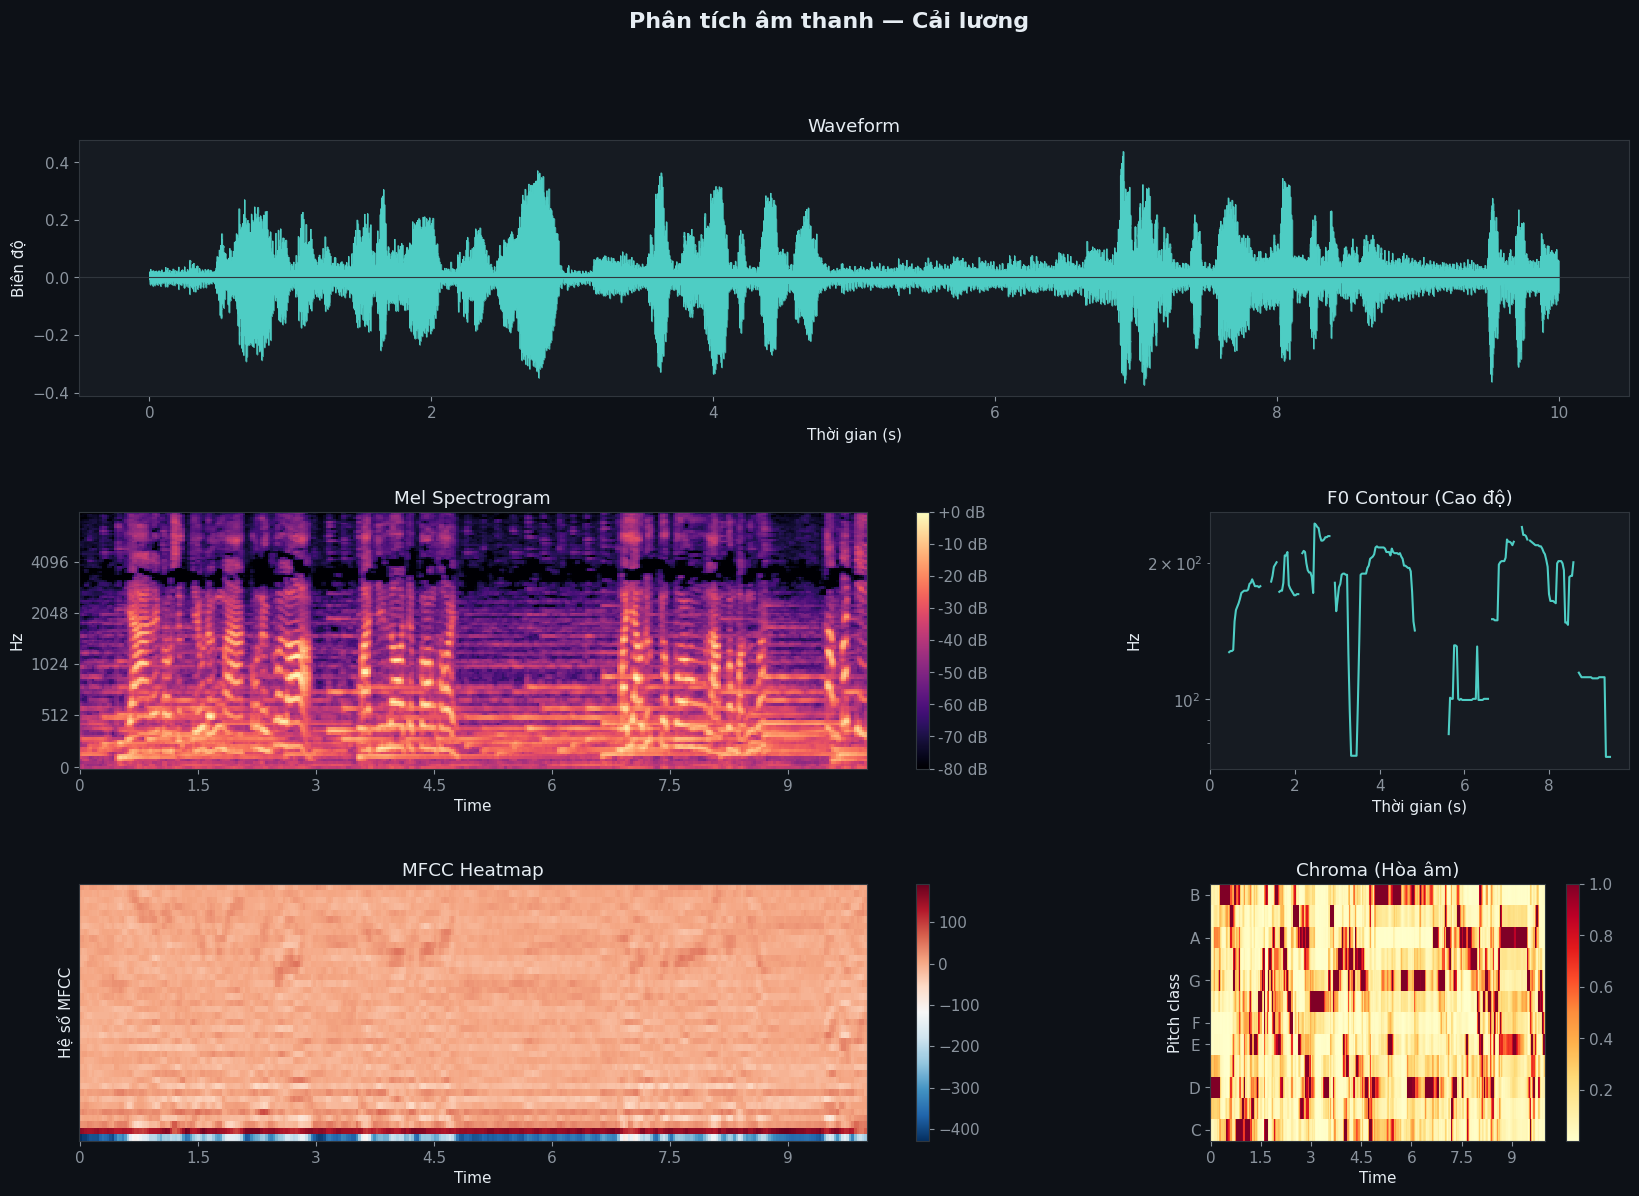


=== Quan họ ===


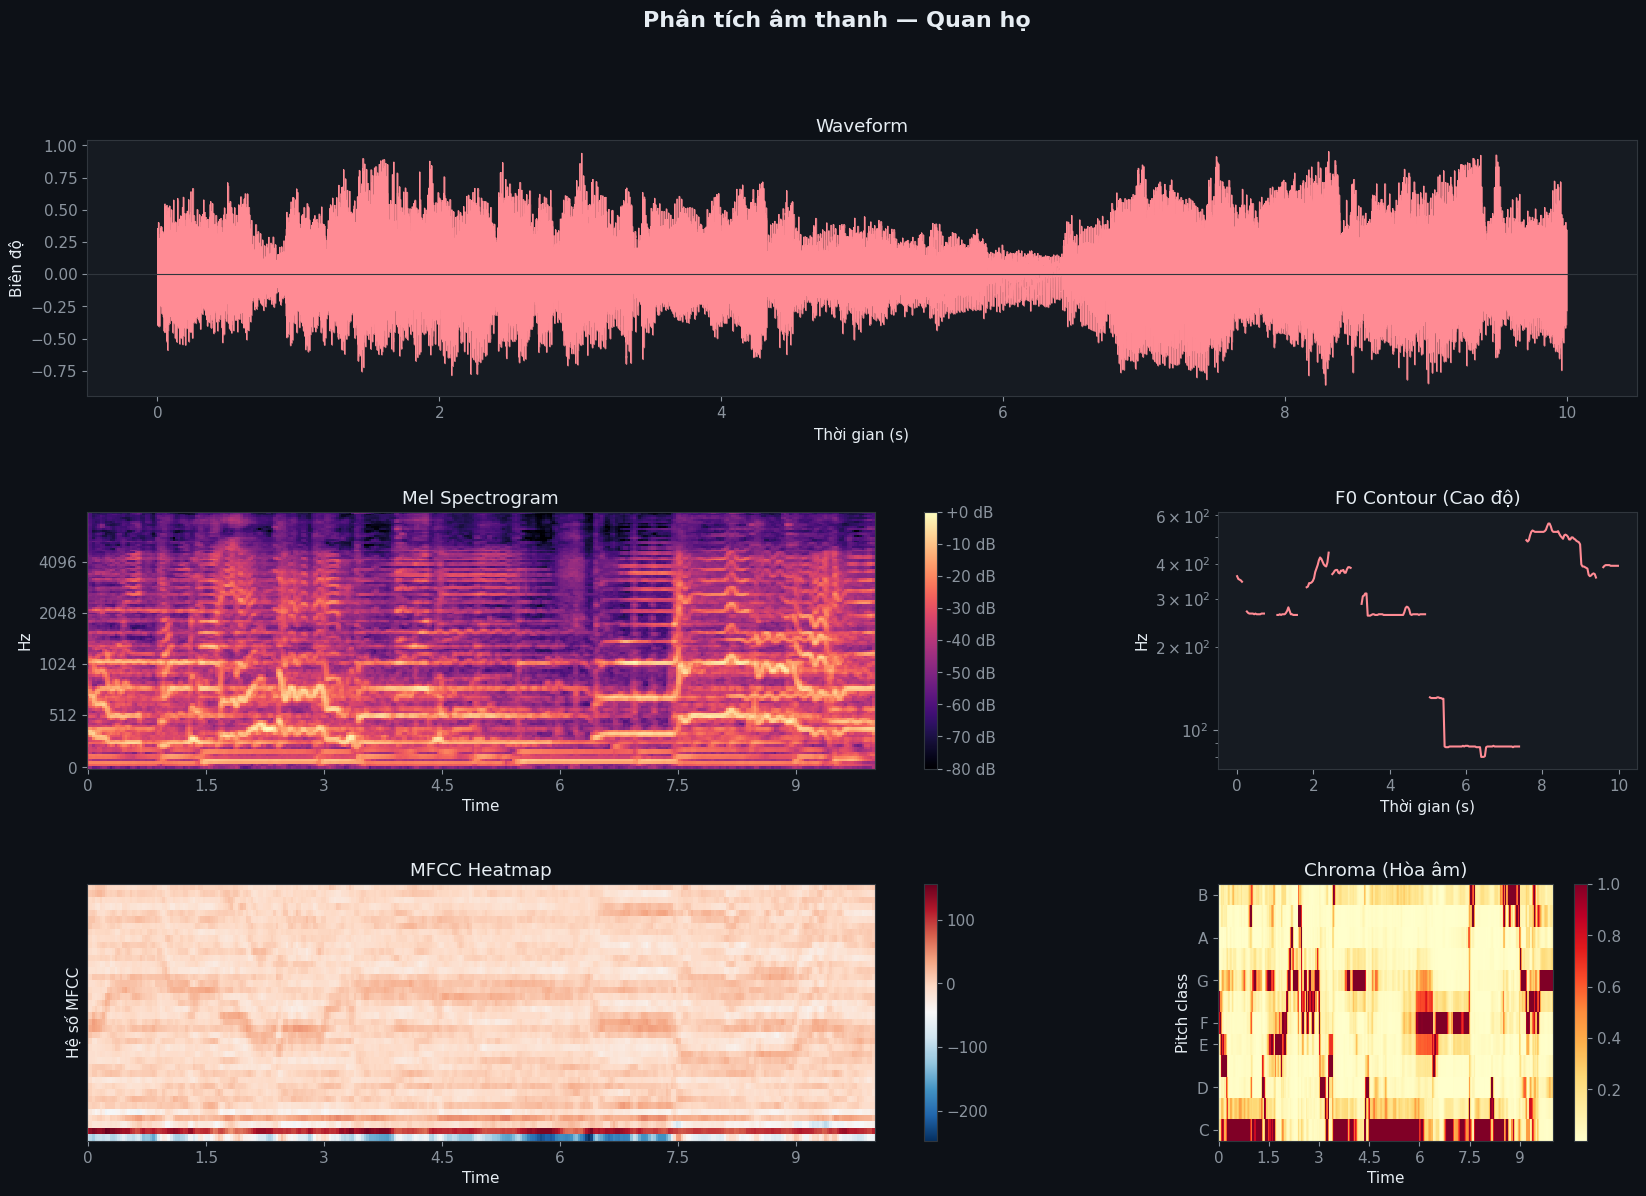


=== Chầu văn ===


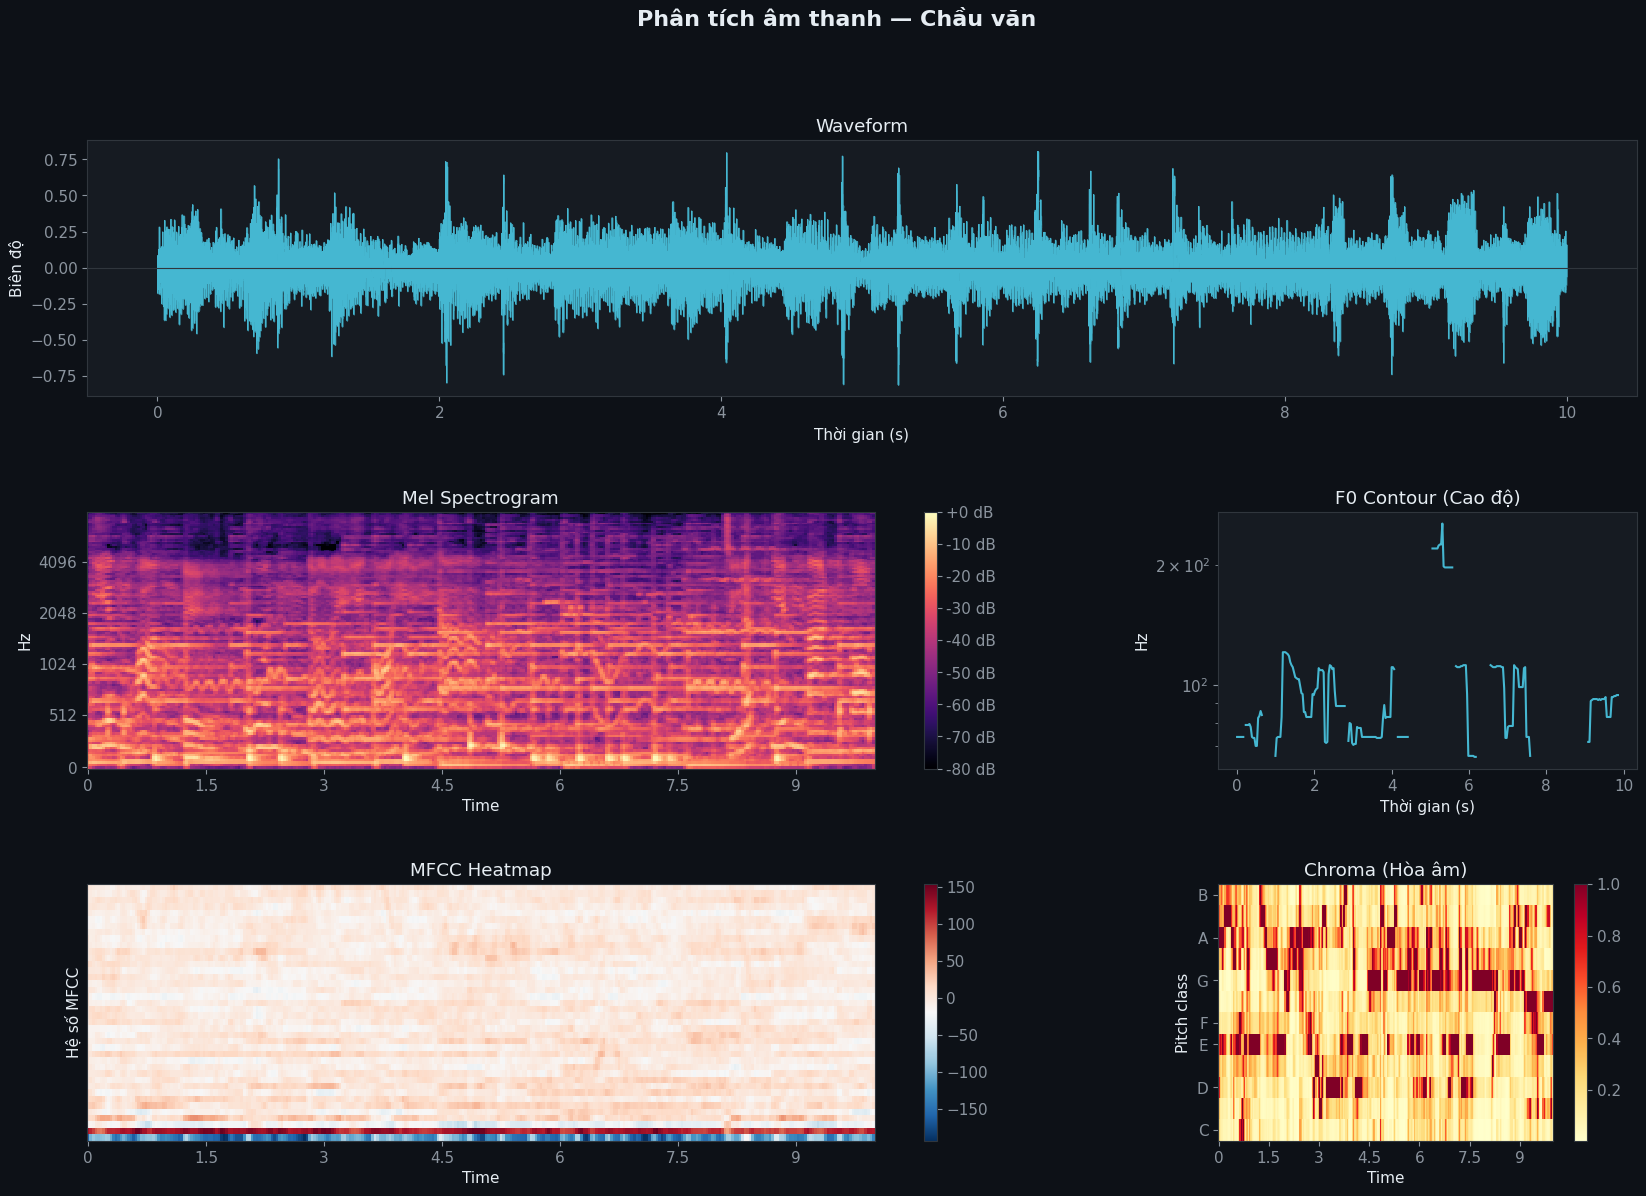


=== Chèo ===


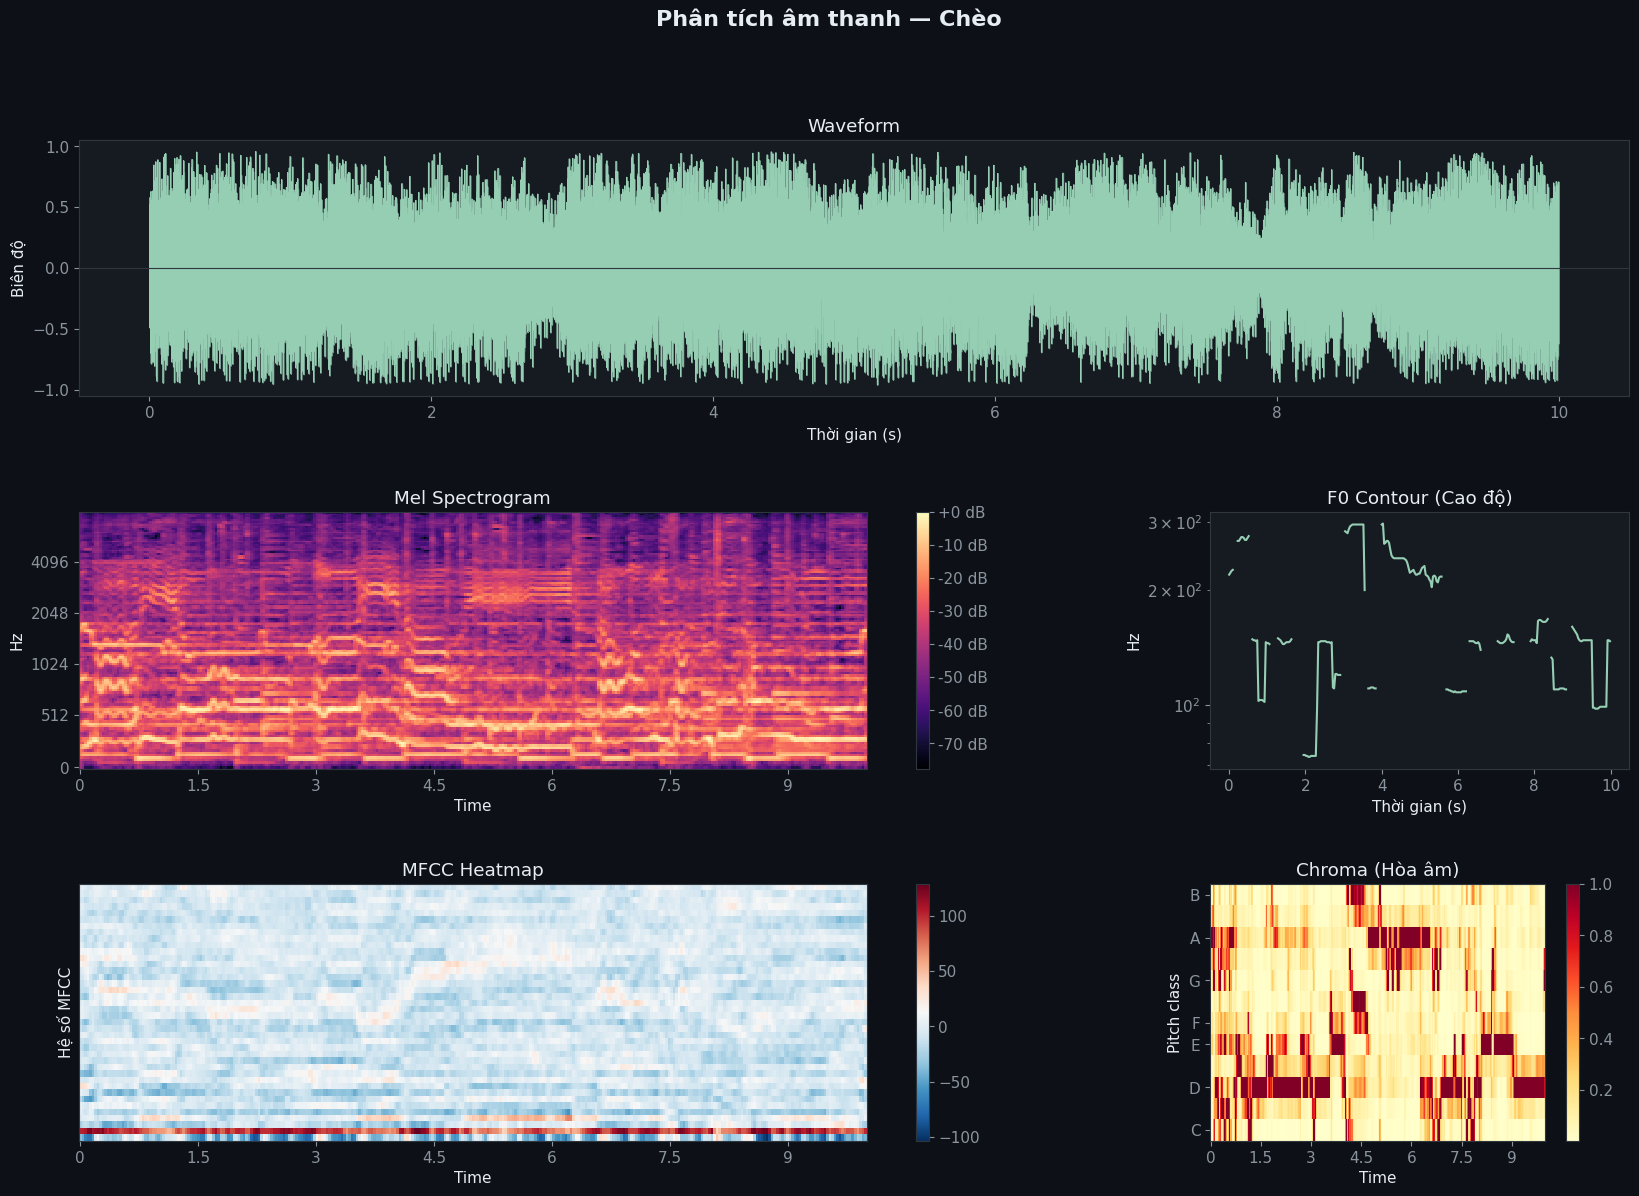


=== Ca trù ===


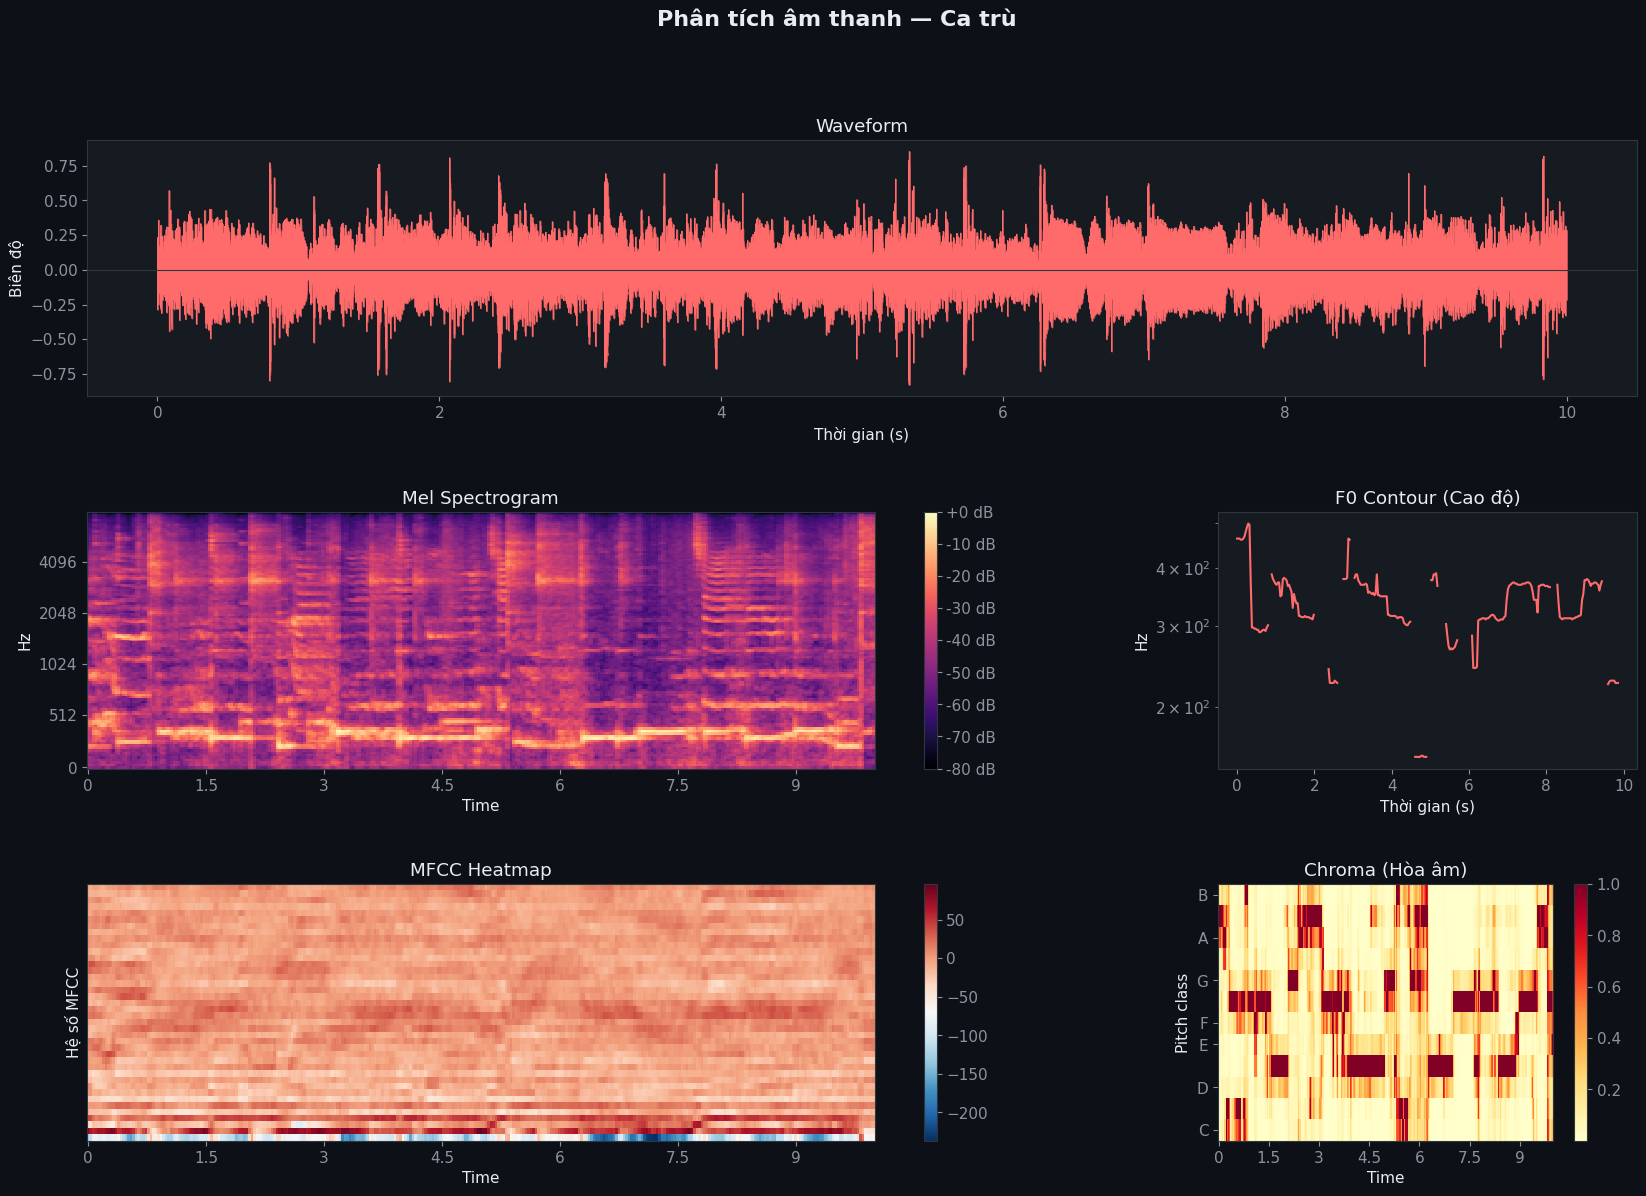


=== Hát xẩm ===


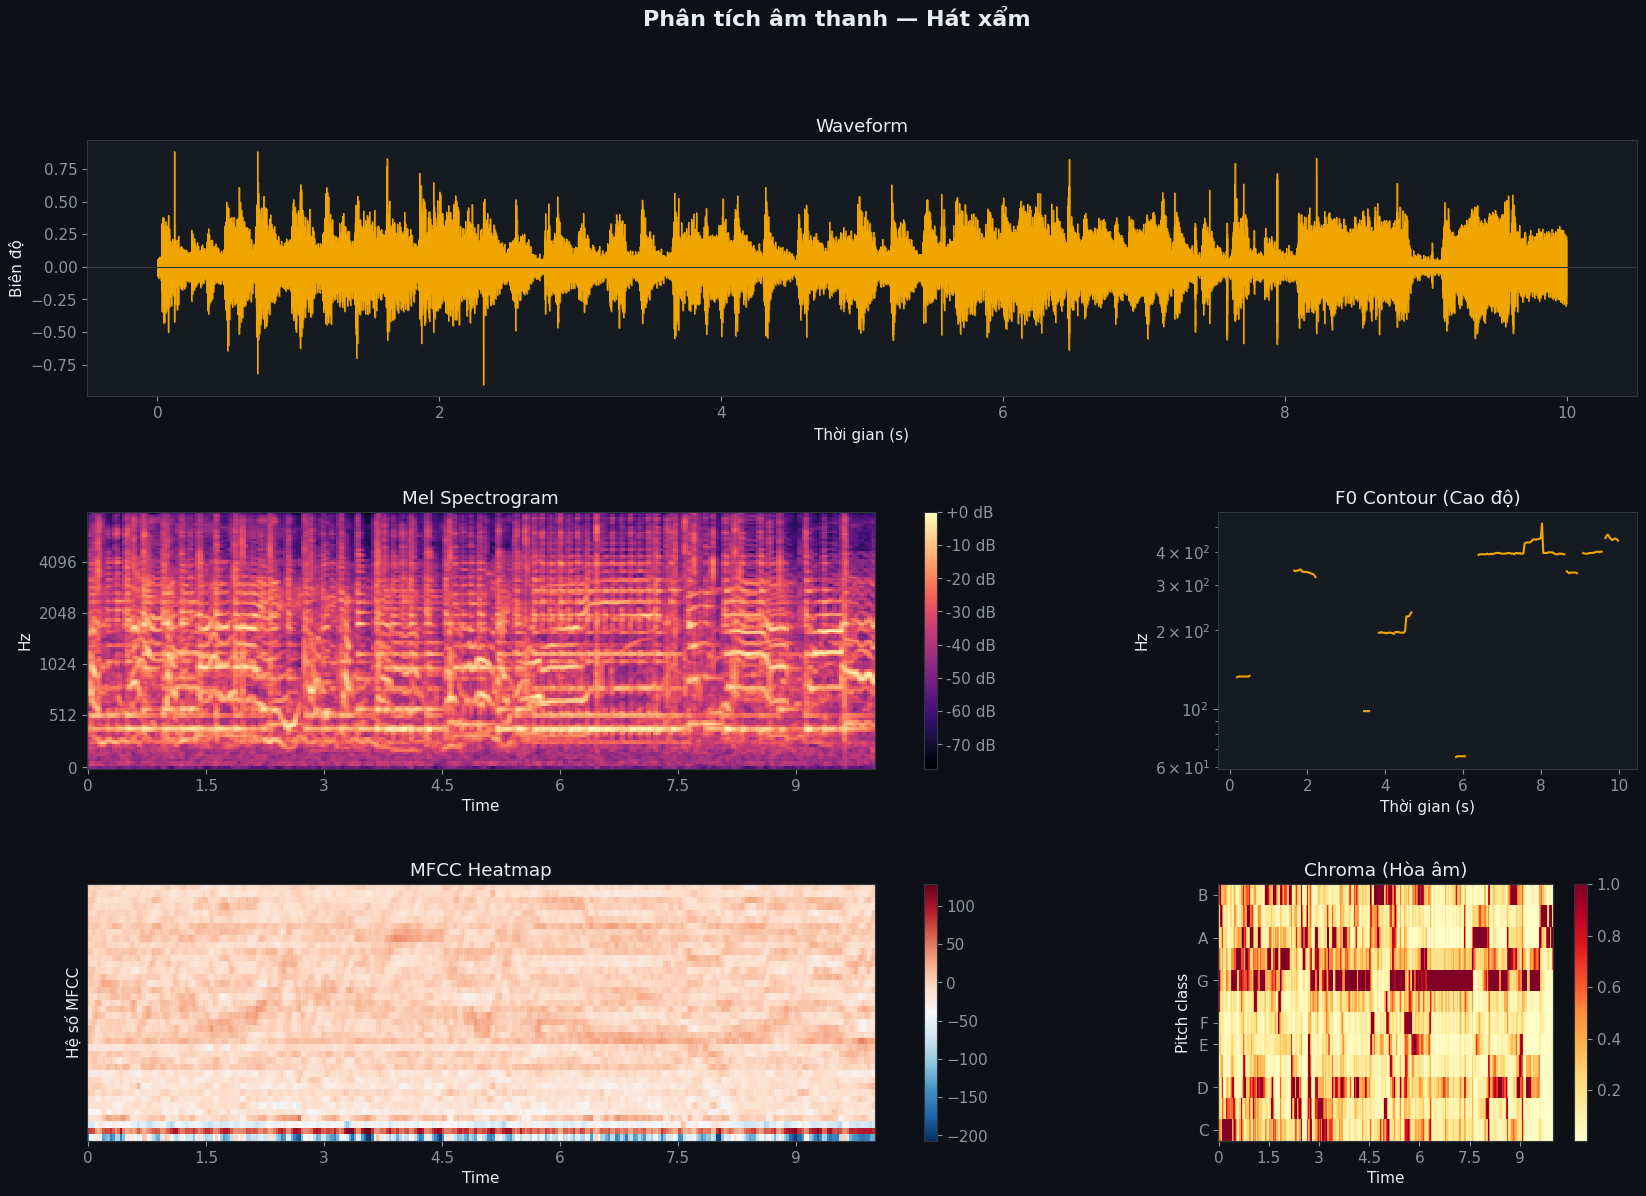

In [9]:
def visualize_sample(r, save=True):
    audio  = r.get('_audio');  sr   = r.get('_sr', SR_TARGET)
    f0     = r.get('_f0');     mfcc = r.get('_mfcc')
    mel    = r.get('_mel');    chroma = r.get('_chroma')
    label  = r.get('label','')
    color  = get_color(label)

    fig = plt.figure(figsize=(20, 13), facecolor='#0d1117')
    fig.suptitle(f'Phân tích âm thanh — {label}',
                 fontsize=16, fontweight='bold', color='#e6edf3', y=0.98)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # Waveform
    ax1 = fig.add_subplot(gs[0, :])
    if audio is not None:
        t = np.linspace(0, len(audio)/sr, len(audio))
        ax1.fill_between(t, audio, alpha=0.7, color=color)
        ax1.plot(t, audio, color=color, lw=0.5)
        ax1.axhline(0, color='#30363d', lw=0.8)
    ax1.set_title('Waveform'); ax1.set_xlabel('Thời gian (s)'); ax1.set_ylabel('Biên độ')

    # Mel Spectrogram
    ax2 = fig.add_subplot(gs[1, :2])
    if mel is not None:
        img = librosa.display.specshow(mel, sr=sr, x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
        plt.colorbar(img, ax=ax2, format='%+2.0f dB')
    ax2.set_title('Mel Spectrogram')

    # F0 Contour
    ax3 = fig.add_subplot(gs[1, 2])
    if f0 is not None:
        ft = librosa.frames_to_time(np.arange(len(f0)), sr=sr, hop_length=512)
        ax3.plot(ft, np.where(np.isnan(f0), np.nan, f0), color=color, lw=1.5)
    ax3.set_title('F0 Contour (Cao độ)')
    ax3.set_yscale('log'); ax3.set_xlabel('Thời gian (s)'); ax3.set_ylabel('Hz')

    # MFCC
    ax4 = fig.add_subplot(gs[2, :2])
    if mfcc is not None:
        img2 = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax4, cmap='RdBu_r')
        plt.colorbar(img2, ax=ax4)
    ax4.set_title('MFCC Heatmap'); ax4.set_ylabel('Hệ số MFCC')

    # Chroma
    ax5 = fig.add_subplot(gs[2, 2])
    if chroma is not None:
        img3 = librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', ax=ax5, cmap='YlOrRd')
        plt.colorbar(img3, ax=ax5)
    ax5.set_title('Chroma (Hòa âm)')

    plt.tight_layout()
    if save:
        lbl_safe = str(label).replace(' ','_').replace('/','_')
        plt.savefig(f'./data/viz_{lbl_safe}.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

seen = set()
for r in results:
    lbl = r.get('label','')
    if lbl not in seen:
        print(f'\n=== {lbl} ===')
        visualize_sample(r)
        seen.add(lbl)

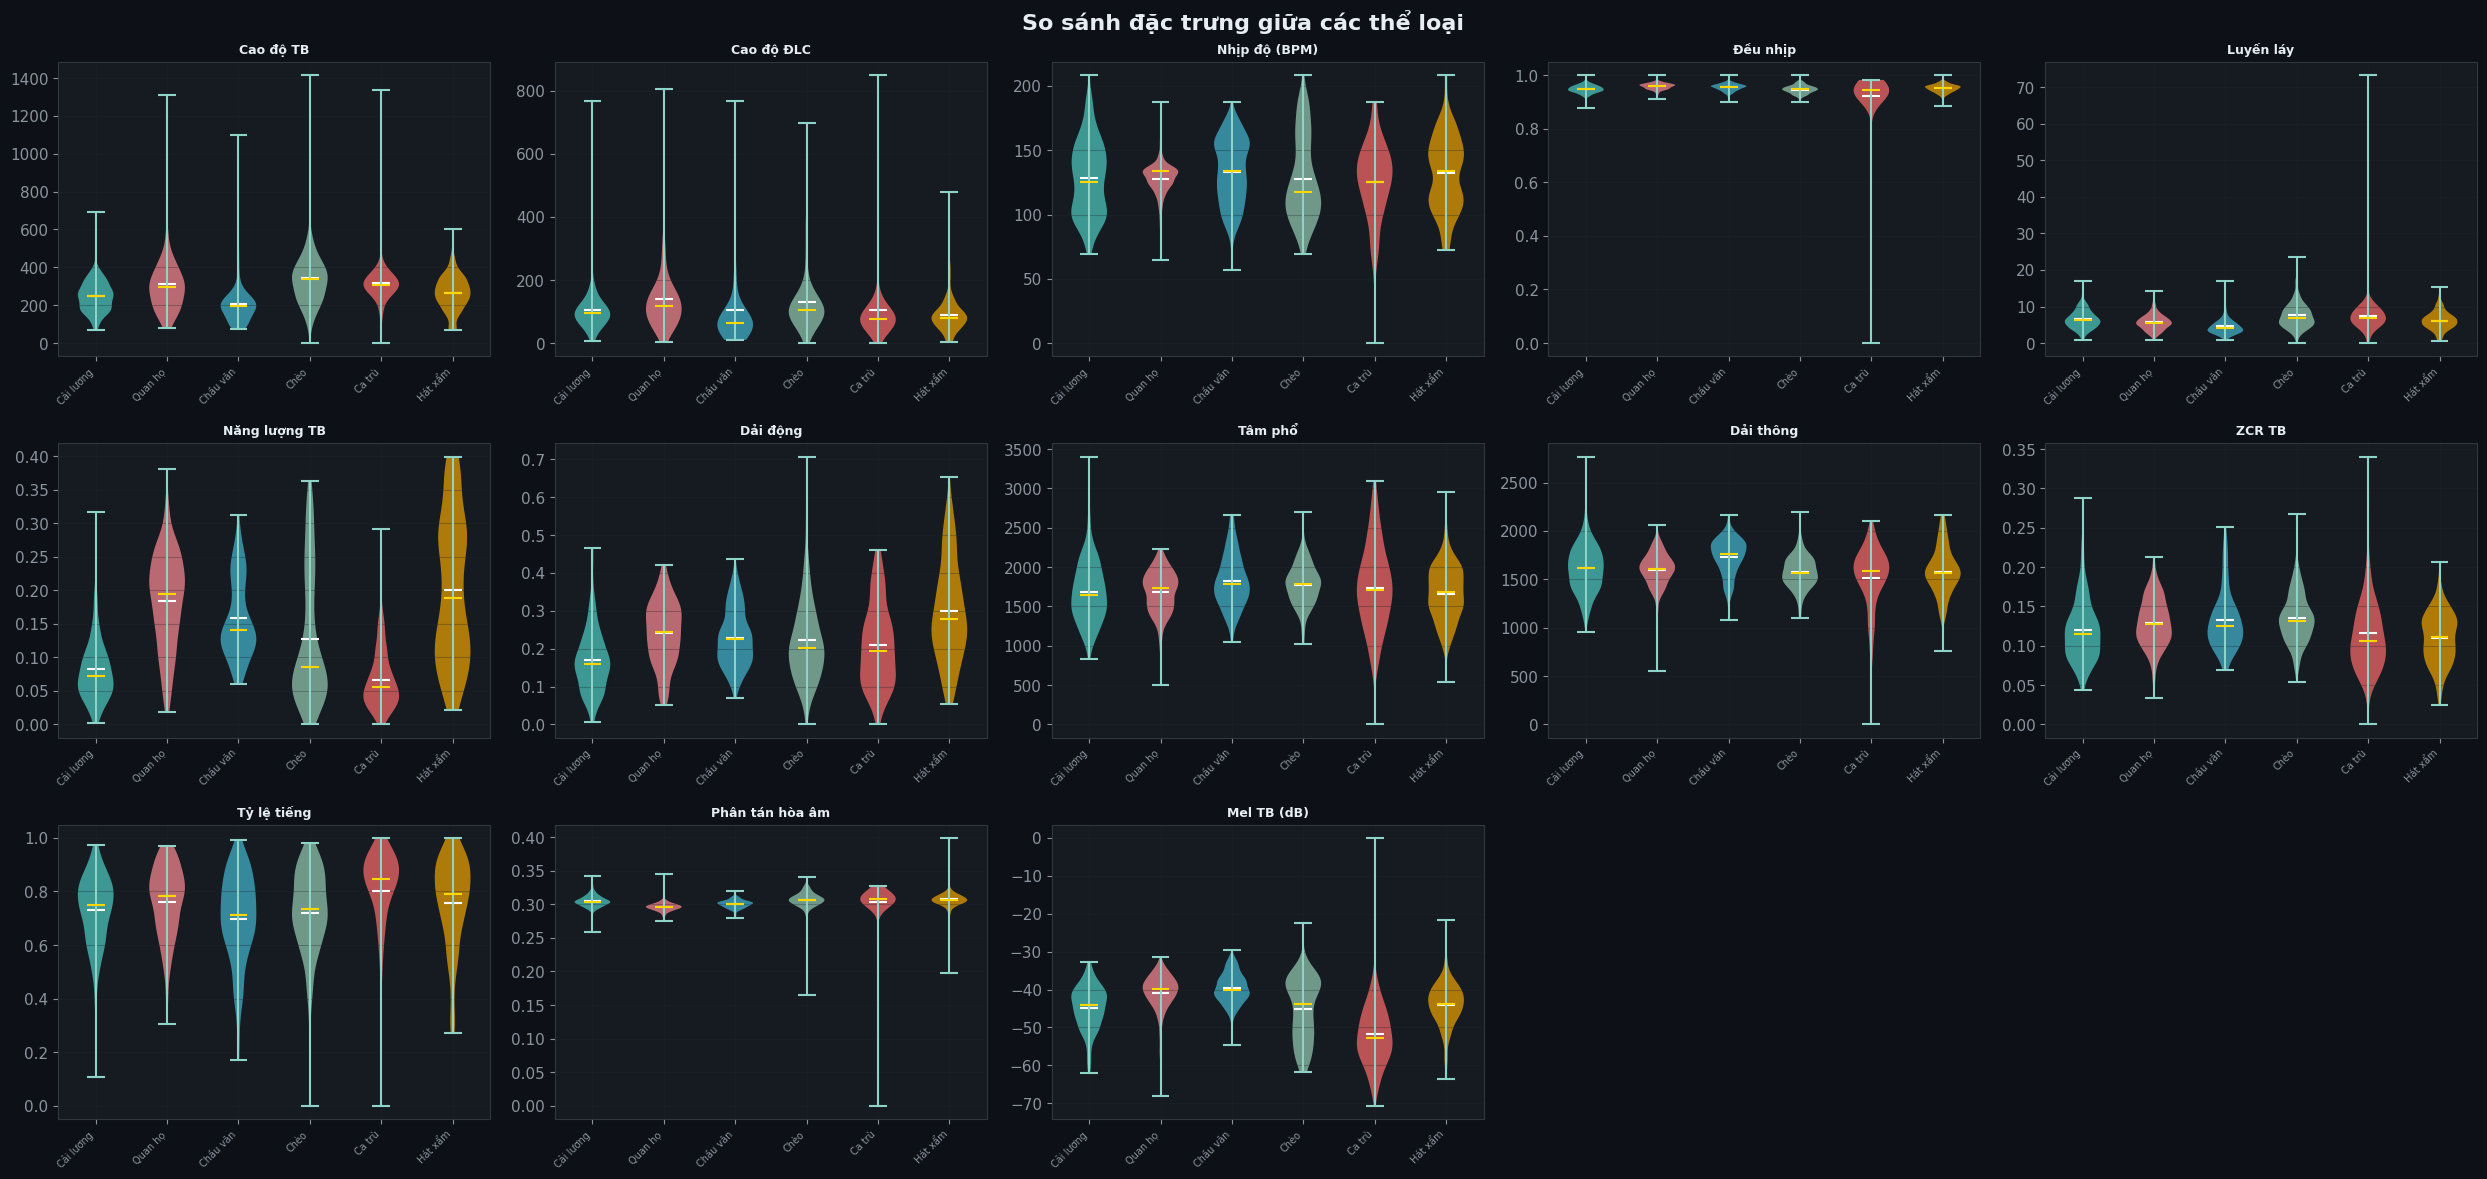

Saved: ./data/02_violin_comparison.png


In [10]:
# Violin plots so sánh đặc trưng
KEY_FEATS = ['pitch_mean','pitch_std','tempo','beat_regularity',
             'vibrato_extent','energy_mean','dynamic_range',
             'spectral_centroid_mean','spectral_bandwidth_mean',
             'zcr_mean','voiced_ratio','chroma_std_overall','mel_mean']

FEAT_LBL = {
    'pitch_mean':'Cao độ TB','pitch_std':'Cao độ ĐLC','tempo':'Nhịp độ (BPM)',
    'beat_regularity':'Đều nhịp','vibrato_extent':'Luyến láy',
    'energy_mean':'Năng lượng TB','dynamic_range':'Dải động',
    'spectral_centroid_mean':'Tâm phổ','spectral_bandwidth_mean':'Dải thông',
    'zcr_mean':'ZCR TB','voiced_ratio':'Tỷ lệ tiếng','chroma_std_overall':'Phân tán hòa âm',
    'mel_mean':'Mel TB (dB)',
}

# Lọc cột hợp lệ
valid_feats = [f for f in KEY_FEATS if f in df.columns and df[f].notna().sum() > 0]
df_num = df[valid_feats + ['label']].dropna()
genres = df_num['label'].unique()

n_feats = len(valid_feats)
cols = 5; rows = (n_feats + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(25, 4*rows), facecolor='#0d1117')
fig.suptitle('So sánh đặc trưng giữa các thể loại', fontsize=16, fontweight='bold',
             color='#e6edf3', y=0.98)

for i, feat in enumerate(valid_feats):
    ax = axes.flatten()[i]
    data_g  = [df_num[df_num['label']==g][feat].dropna().values for g in genres]
    data_g  = [d for d in data_g if len(d) > 0]
    cv      = [get_color(g) for g in genres if len(df_num[df_num['label']==g][feat].dropna()) > 0]
    parts = ax.violinplot(data_g, positions=range(len(data_g)), showmeans=True, showmedians=True)
    for pc, c in zip(parts['bodies'], cv):
        pc.set_facecolor(c); pc.set_alpha(0.7)
    parts['cmeans'].set_color('white')
    parts['cmedians'].set_color('#FFD700')
    ax.set_xticks(range(len(genres)))
    ax.set_xticklabels(genres, rotation=45, ha='right', fontsize=7)
    ax.set_title(FEAT_LBL.get(feat, feat), fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)

for ax in axes.flatten()[n_feats:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('./data/02_violin_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/02_violin_comparison.png')

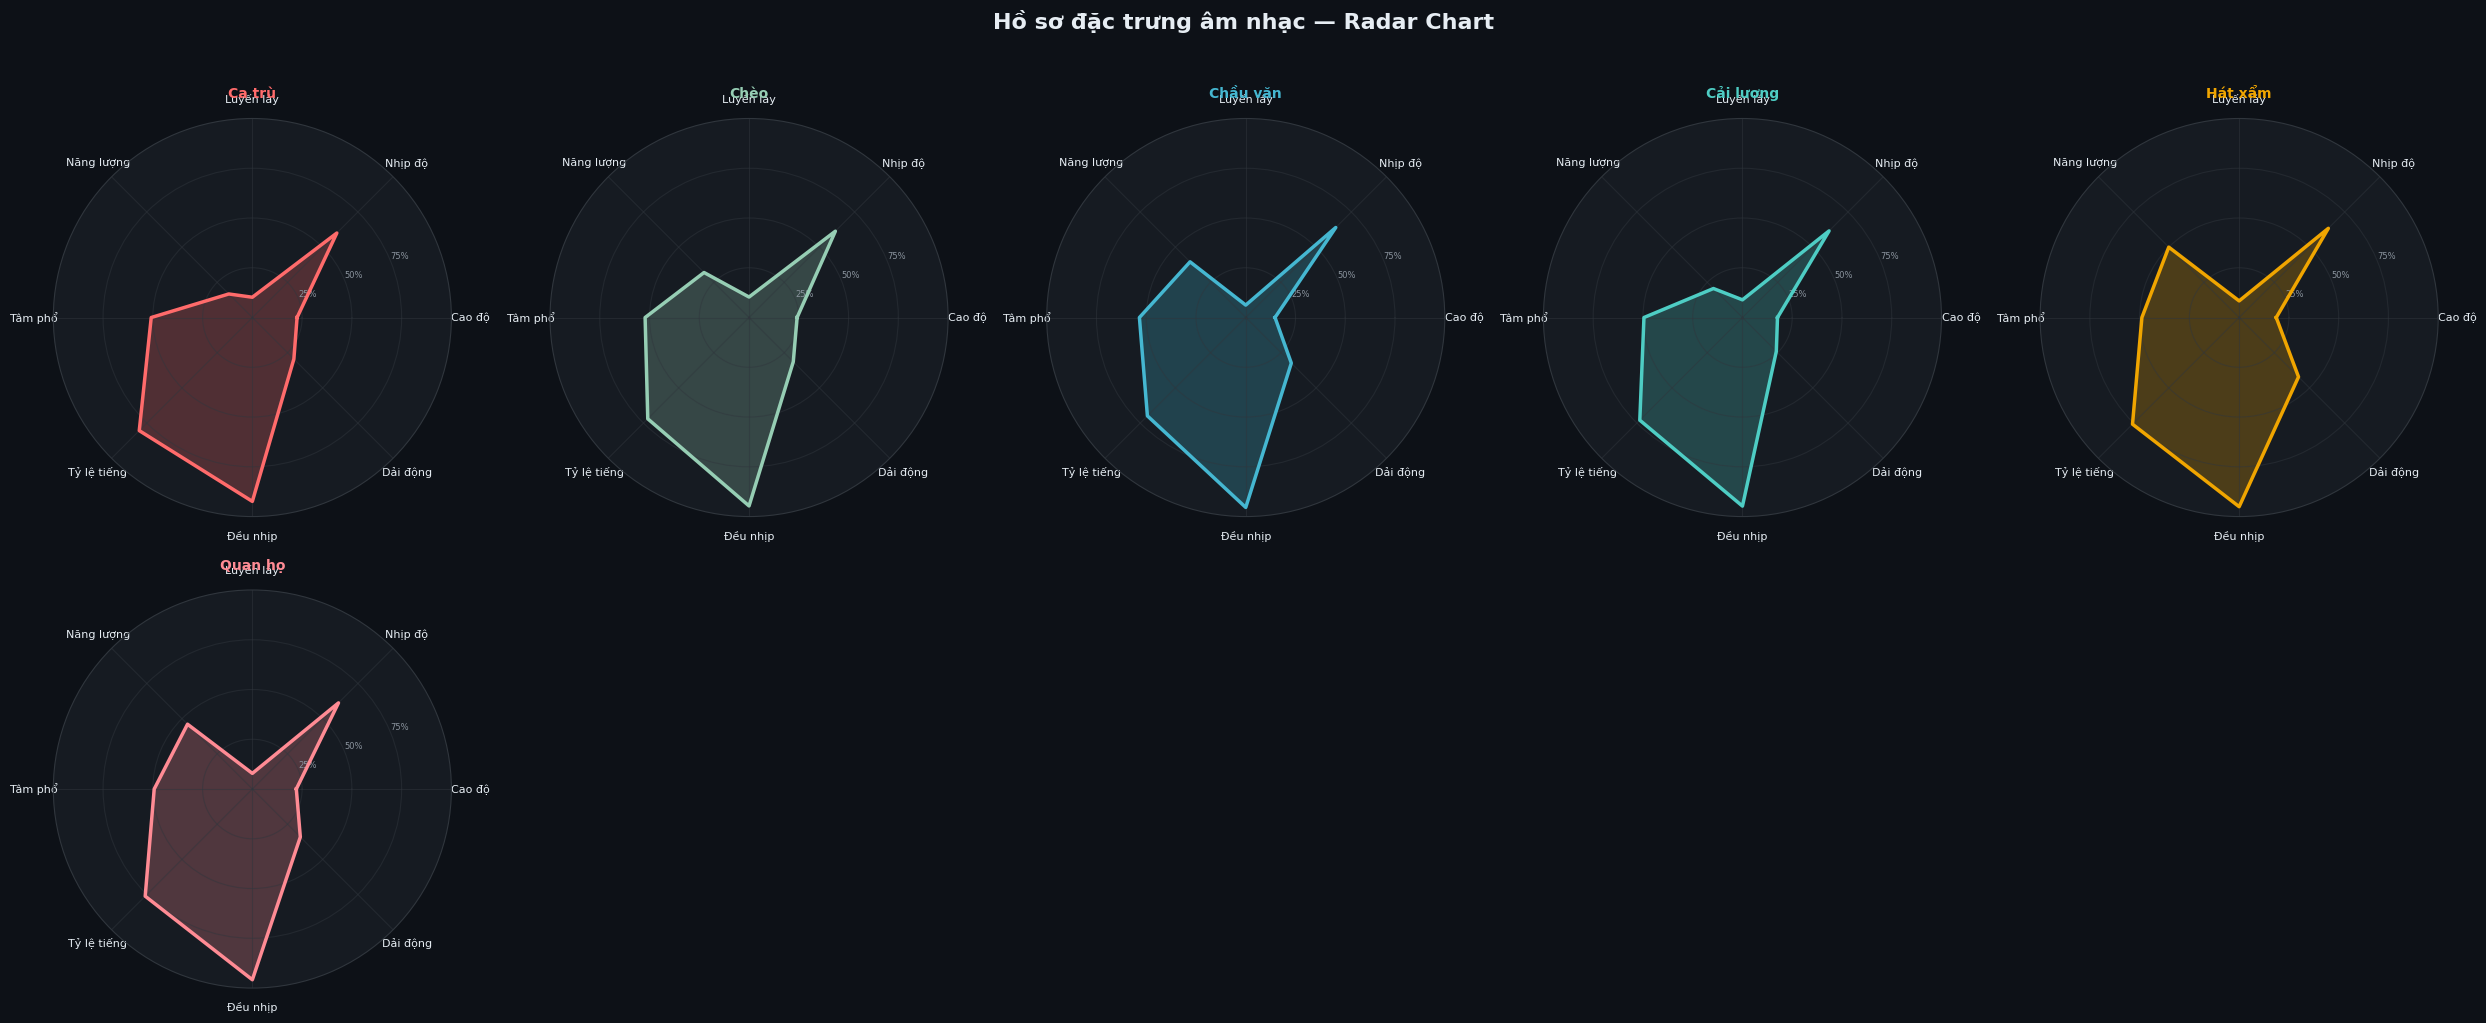

Saved: ./data/03_radar_chart.png


In [11]:
# Radar chart
radar_feats  = [f for f in ['pitch_mean','tempo','vibrato_extent','energy_mean',
                'spectral_centroid_mean','voiced_ratio','beat_regularity','dynamic_range']
                if f in df_num.columns]
radar_labels = ['Cao độ','Nhịp độ','Luyến láy','Năng lượng',
                'Tâm phổ','Tỷ lệ tiếng','Đều nhịp','Dải động'][:len(radar_feats)]

scaler_r = MinMaxScaler()
df_rr    = df_num[radar_feats].dropna()
df_rn    = pd.DataFrame(scaler_r.fit_transform(df_rr), columns=radar_feats, index=df_rr.index)
df_rn['label'] = df_num.loc[df_rr.index, 'label']
gmeans   = df_rn.groupby('label')[radar_feats].mean()

n_f    = len(radar_feats)
angles = np.linspace(0, 2*np.pi, n_f, endpoint=False).tolist() + [0]

n_genres = len(gmeans)
cols_r = min(5, n_genres); rows_r = (n_genres + cols_r - 1) // cols_r

fig, axes_r = plt.subplots(rows_r, cols_r, figsize=(5*cols_r, 5*rows_r),
                            subplot_kw=dict(polar=True), facecolor='#0d1117')
fig.suptitle('Hồ sơ đặc trưng âm nhạc — Radar Chart',
             fontsize=16, fontweight='bold', color='#e6edf3', y=1.02)

axes_flat = np.array(axes_r).flatten() if n_genres > 1 else [axes_r]
for idx, genre in enumerate(gmeans.index):
    ax  = axes_flat[idx]
    vals = gmeans.loc[genre].tolist() + [gmeans.loc[genre].tolist()[0]]
    c   = get_color(genre)
    ax.plot(angles[:len(vals)], vals, color=c, lw=2.5)
    ax.fill(angles[:len(vals)], vals, color=c, alpha=0.25)
    ax.set_xticks(angles[:n_f])
    ax.set_xticklabels(radar_labels, size=8, color='#e6edf3')
    ax.set_ylim(0, 1); ax.set_yticks([0.25,0.5,0.75])
    ax.set_yticklabels(['25%','50%','75%'], size=6, color='#8b949e')
    ax.grid(color='#30363d', alpha=0.5); ax.set_facecolor('#161b22')
    ax.set_title(genre, size=10, color=c, fontweight='bold', pad=15)

for ax in axes_flat[n_genres:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('./data/03_radar_chart.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/03_radar_chart.png')

Chạy t-SNE...
Xong!


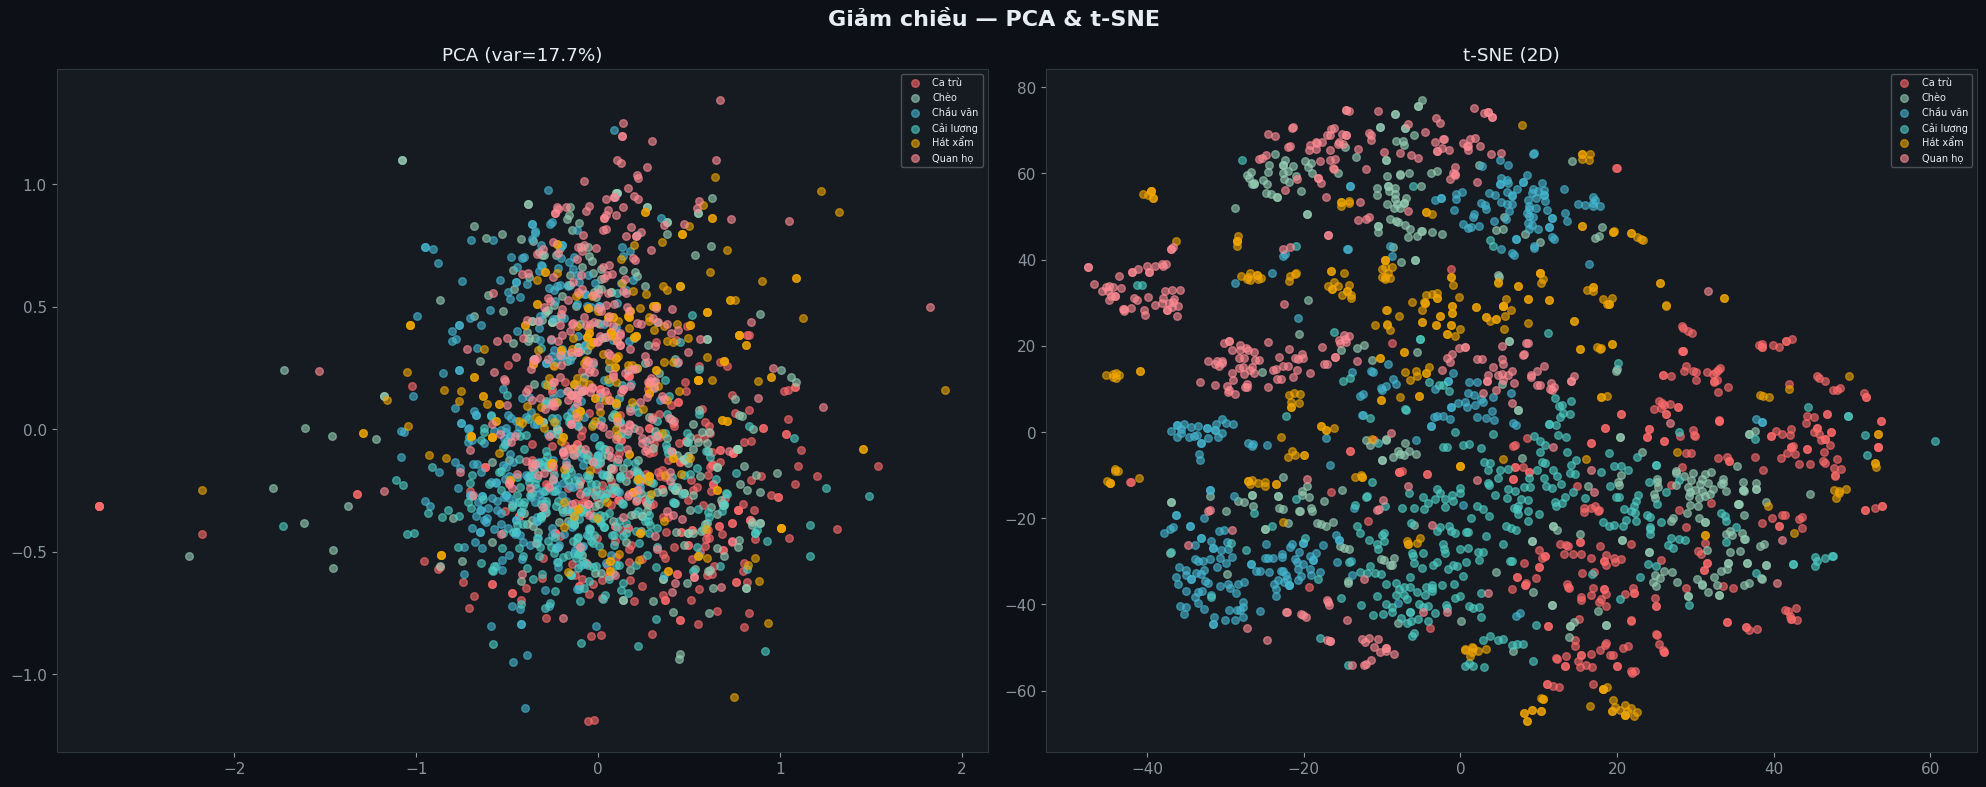

In [12]:
# PCA + t-SNE
feat_cols = [c for c in df.columns
             if c not in ['label','sample_idx'] and not c.startswith('_')
             and pd.api.types.is_float_dtype(df[c])]
X  = df[feat_cols].fillna(0).values
yl = df['label'].values

scaler = MinMaxScaler()  # Chuẩn hóa [0, 1] cho toàn bộ đặc trưng
Xs = scaler.fit_transform(X)

pca = PCA(n_components=min(50, X.shape[1]), random_state=42)
Xp  = pca.fit_transform(Xs)

print('Chạy t-SNE...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Xt   = tsne.fit_transform(Xp[:, :20])
print('Xong!')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(20, 8), facecolor='#0d1117')
fig.suptitle('Giảm chiều — PCA & t-SNE', fontsize=16, fontweight='bold', color='#e6edf3')
for genre in np.unique(yl):
    m = yl==genre; c = get_color(genre)
    a1.scatter(Xp[m,0], Xp[m,1], c=c, label=genre, alpha=0.6, s=30)
    a2.scatter(Xt[m,0], Xt[m,1], c=c, label=genre, alpha=0.6, s=30)
a1.set_title(f'PCA (var={pca.explained_variance_ratio_[:2].sum()*100:.1f}%)')
a1.legend(fontsize=7, framealpha=0.3)
a2.set_title('t-SNE (2D)'); a2.legend(fontsize=7, framealpha=0.3)
plt.tight_layout()
plt.savefig('./data/04_pca_tsne.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


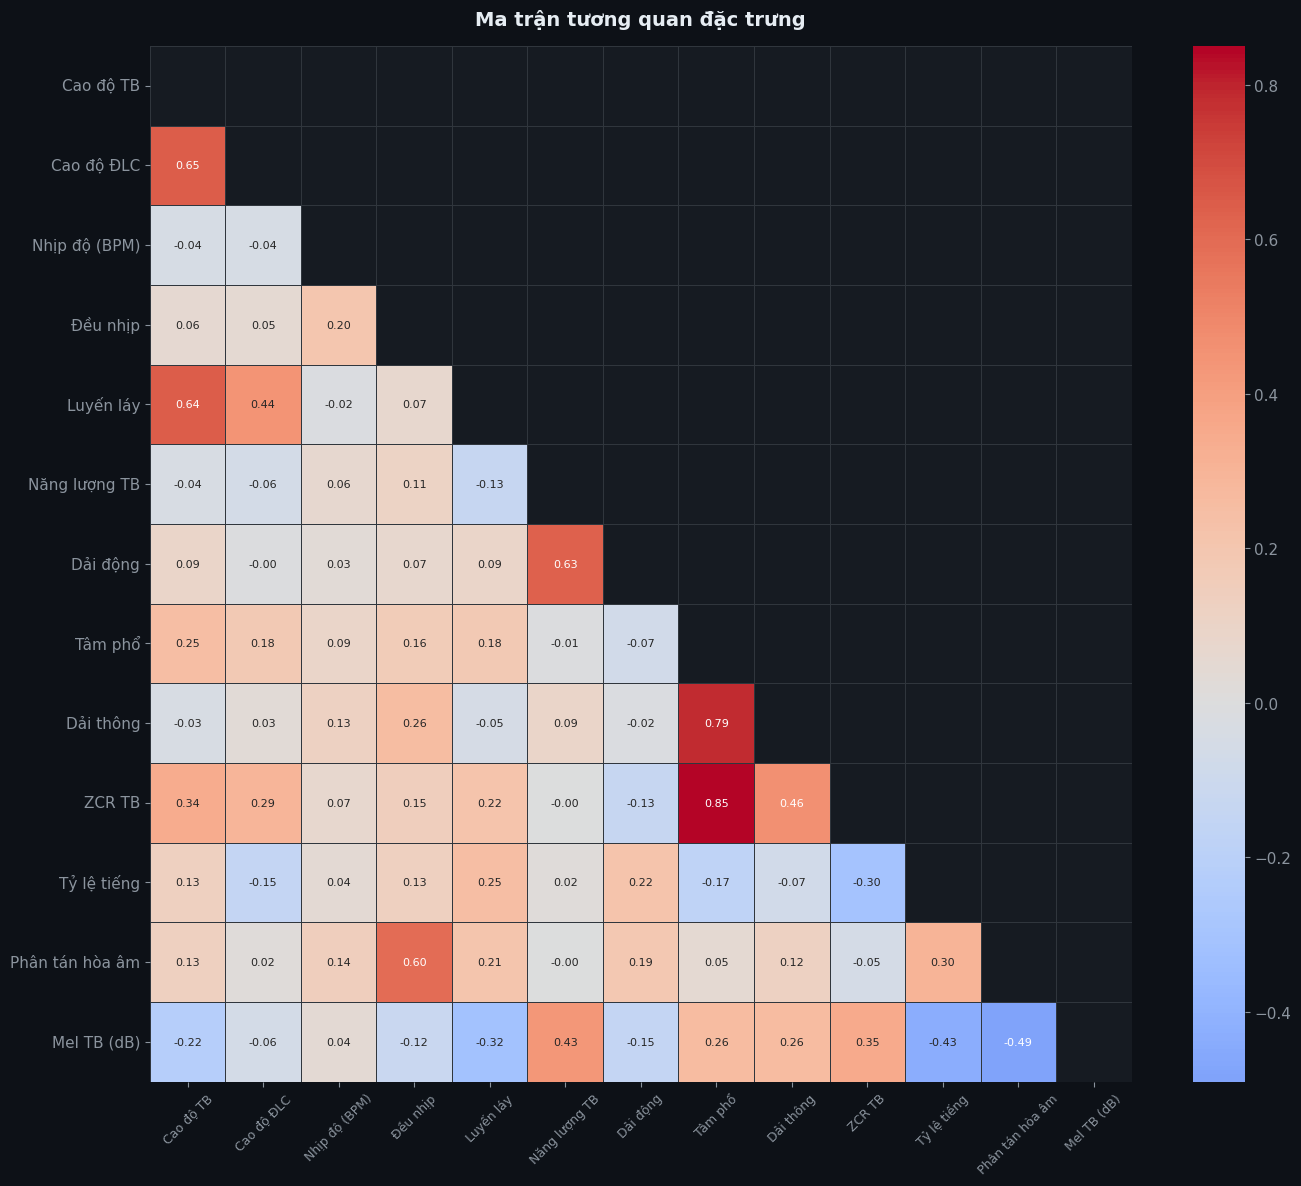

Saved: ./data/05_correlation.png


In [13]:
# Correlation heatmap
valid_for_corr = [f for f in KEY_FEATS if f in df.columns and df[f].notna().sum() > 10]
corr = df[valid_for_corr].corr()

fig, ax = plt.subplots(figsize=(14, 12), facecolor='#0d1117')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, linecolor='#30363d', annot_kws={'size':8},
            xticklabels=[FEAT_LBL.get(f,f) for f in valid_for_corr],
            yticklabels=[FEAT_LBL.get(f,f) for f in valid_for_corr])
ax.set_title('Ma trận tương quan đặc trưng', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.savefig('./data/05_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/05_correlation.png')

## Bước 4: Phân Cụm Fuzzy

In [14]:
# Các trục đặc trưng để phân cụm và số mức độ mờ (Fuzzy Levels) dựa trên nghiên cứu chuyên ngành
FUZZY_AXES = {
    'Energy':   ['energy_mean', 'dynamic_range'],
    'Harmony':  [f'chroma_{n}_mean' for n in ['C','D','E','F','G','A','B']],
    'Pitch':    ['pitch_mean', 'pitch_range'],
    'Spectral': ['spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean'],
    'Tempo':    ['tempo'],
    'Timbre':   [f'mfcc_{i:02d}_mean' for i in range(1, 14)],
    'Vibrato':  ['vibrato_extent', 'vibrato_energy'],
}

# Cấu hình số mức độ mờ (Fuzzy Granularity) theo y văn chuyên ngành
FUZZY_LEVELS = {
    'Energy':   5,  # Rất yếu, Yếu, Vừa, Mạnh, Rất mạnh
    'Harmony':  3,  # Thấp, Trung bình, Cao
    'Pitch':    5,  # Rất trầm, Trầm, Trung, Cao, Rất cao
    'Spectral': 3,  # Thấp, Trung bình, Cao
    'Tempo':    3,  # Chậm, Vừa, Nhanh
    'Timbre':   5,  # Rất thấp, Thấp, Trung bình, Cao, Rất cao
    'Vibrato':  3,  # Ít luyến, Vừa, Nhiều luyến
}

feat_col_idx = {c: i for i, c in enumerate(feat_cols)}

def find_optimal_k(Xax, k_range=range(2, 8)):
    inertias, silhs, bics = [], [], []
    Xax = np.nan_to_num(Xax)
    for k in k_range:
        km  = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xax)
        inertias.append(km.inertia_)
        silhs.append(silhouette_score(Xax, km.labels_) if k > 1 else 0)
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=5).fit(Xax)
        bics.append(gmm.bic(Xax))
    ks = list(k_range)
    d2 = np.diff(np.diff(np.array(inertias)))
    ek = ks[np.argmax(d2) + 1] if len(d2) > 0 else ks[0]
    sk = ks[np.argmax(silhs)]
    bk = ks[np.argmin(bics)]
    ok = Counter([ek, sk, bk]).most_common(1)[0][0]
    return dict(opt=ok, elbow=ek, silh=sk, bic=bk,
                inertias=inertias, silhs=silhs, bics=bics, ks=ks)

print('Khảo sát số cụm tối ưu toán học (để đối chiếu):')
opt_k = {}
for ax_name, ax_feats in FUZZY_AXES.items():
    vf   = [f for f in ax_feats if f in feat_col_idx]
    if not vf: print(f'  {ax_name}: bỏ qua (không có đặc trưng)'); continue
    cidx = [feat_col_idx[f] for f in vf]
    Xax  = np.nan_to_num(Xs[:, cidx])
    res  = find_optimal_k(Xax)
    opt_k[ax_name] = res
    print(f'  {ax_name:10s}: Elbow/BIC gợi ý k={res["opt"]} | Cấu hình nghiên cứu chọn k={FUZZY_LEVELS[ax_name]}')
print('\nThiết lập phân vùng mờ hoàn tất!')


Tìm số cụm tối ưu cho từng trục...
  Tempo     : elbow=3 silh=7 BIC=6 → k=3
  Pitch     : elbow=3 silh=2 BIC=5 → k=3
  Vibrato   : elbow=3 silh=2 BIC=7 → k=3
  Energy    : elbow=3 silh=2 BIC=7 → k=3
  Timbre    : elbow=4 silh=2 BIC=3 → k=4
  Harmony   : elbow=4 silh=4 BIC=6 → k=4
  Spectral  : elbow=3 silh=2 BIC=5 → k=3

Xong!


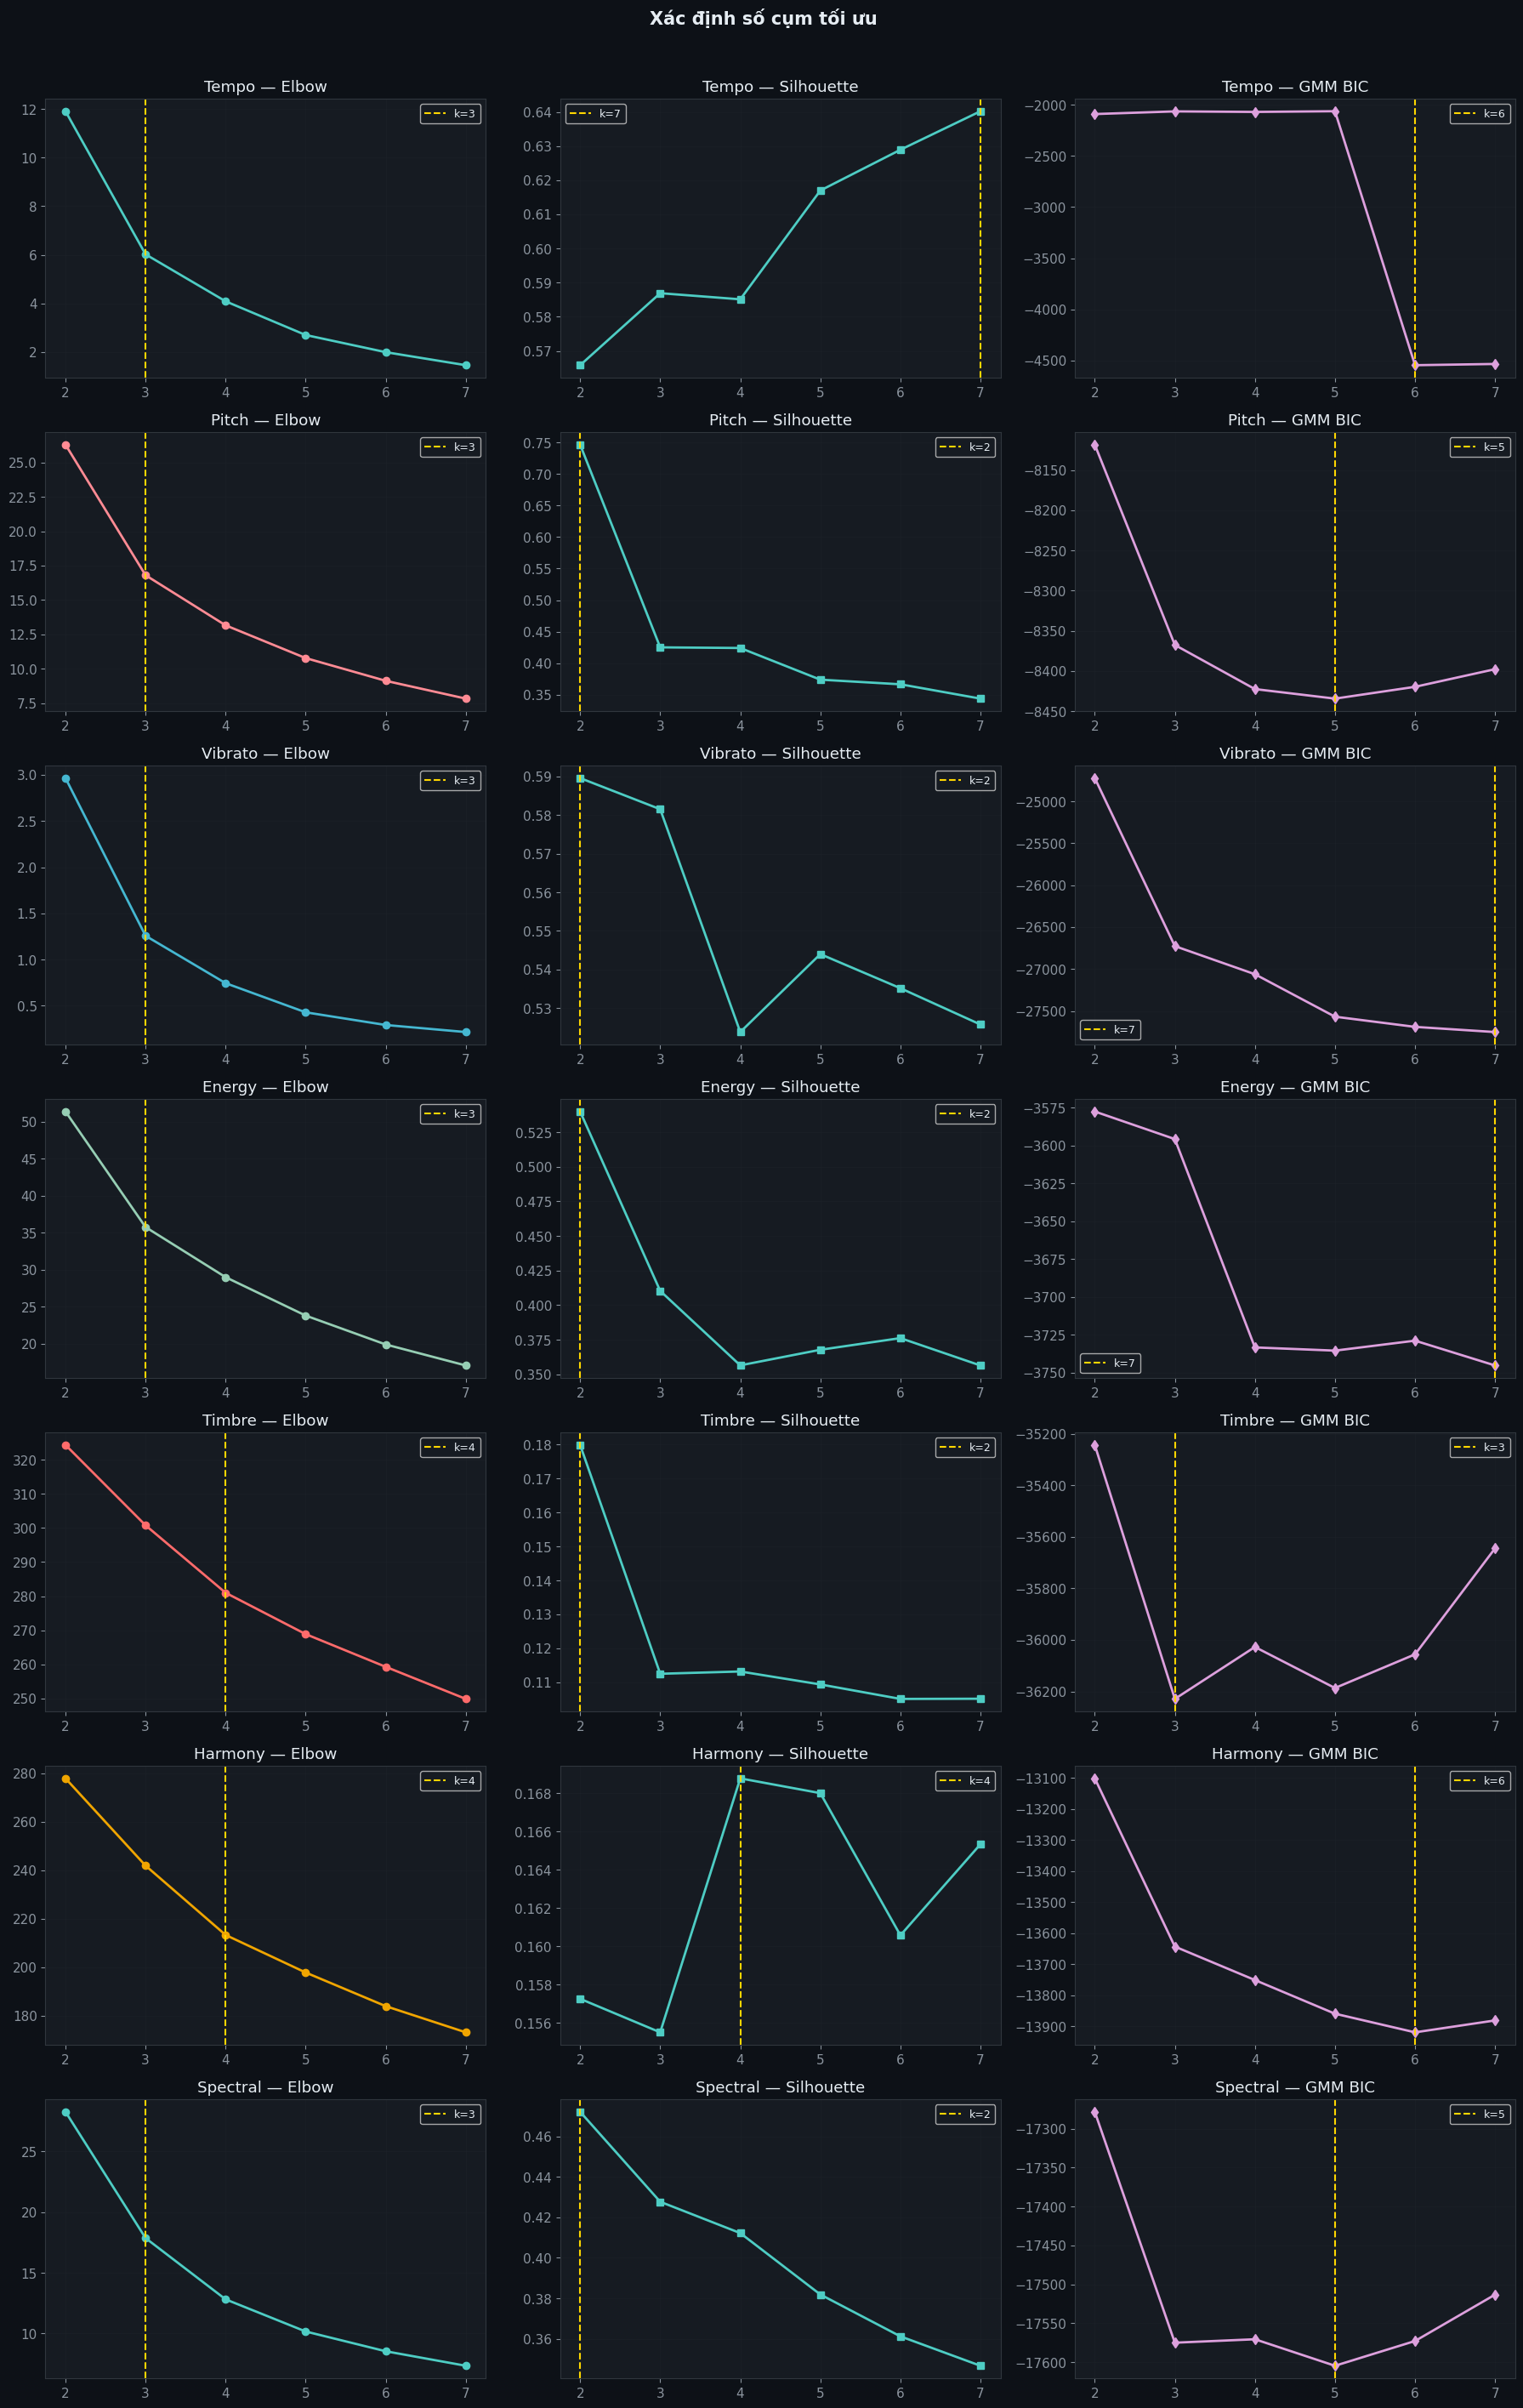

Saved: ./data/06_optimal_k.png


In [15]:
# Elbow / Silhouette / BIC plots
n_ax = len(opt_k)
fig, axg = plt.subplots(n_ax, 3, figsize=(18, 4*n_ax), facecolor='#0d1117')
fig.suptitle('Xác định số cụm tối ưu', fontsize=15, fontweight='bold', color='#e6edf3', y=1.01)
if n_ax == 1: axg = [axg]

COLS = list(GENRE_COLORS.values())
for ri, (ax_name, res) in enumerate(opt_k.items()):
    c = COLS[ri % len(COLS)]; ks = res['ks']; row = axg[ri]
    row[0].plot(ks,res['inertias'],'o-',color=c,lw=2,ms=6)
    row[0].axvline(res['elbow'],color='#FFD700',ls='--',label=f'k={res["elbow"]}')
    row[0].set_title(f'{ax_name} — Elbow'); row[0].legend(fontsize=9); row[0].grid(alpha=0.3)
    row[1].plot(ks,res['silhs'],'s-',color='#4ECDC4',lw=2,ms=6)
    row[1].axvline(res['silh'],color='#FFD700',ls='--',label=f'k={res["silh"]}')
    row[1].set_title(f'{ax_name} — Silhouette'); row[1].legend(fontsize=9); row[1].grid(alpha=0.3)
    row[2].plot(ks,res['bics'],'d-',color='#DDA0DD',lw=2,ms=6)
    row[2].axvline(res['bic'],color='#FFD700',ls='--',label=f'k={res["bic"]}')
    row[2].set_title(f'{ax_name} — GMM BIC'); row[2].legend(fontsize=9); row[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./data/06_optimal_k.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/06_optimal_k.png')

In [16]:
# Fuzzy C-Means với cấu hình mức độ mờ nghiên cứu (Tổng cộng 27 mức độ trên 7 trục)
LING = {
    2: ['Thấp','Cao'],
    3: ['Thấp','Trung bình','Cao'],
    4: ['Rất thấp','Thấp','Trung bình','Cao'],
    5: ['Rất thấp','Thấp','Trung bình','Cao','Rất cao'],
    6: ['Cực thấp','Rất thấp','Thấp','Trung bình','Cao','Rất cao'],
}
MUSIC_L = {
    'Energy':   {5: ['Rất yếu', 'Yếu', 'Vừa', 'Mạnh', 'Rất mạnh']},
    'Harmony':  {3: ['Thấp', 'Trung bình', 'Cao']},
    'Pitch':    {5: ['Rất trầm', 'Trầm', 'Trung', 'Cao', 'Rất cao']},
    'Spectral': {3: ['Thấp', 'Trung bình', 'Cao']},
    'Tempo':    {3: ['Chậm', 'Vừa', 'Nhanh']},
    'Timbre':   {5: ['Rất thấp', 'Thấp', 'Trung bình', 'Cao', 'Rất cao']},
    'Vibrato':  {3: ['Ít luyến', 'Vừa', 'Nhiều luyến']},
}

fcm_res = {}
crisp_dict = {'sample_idx': df['sample_idx'], 'label': df['label']}
continuous_dict = {'sample_idx': df['sample_idx'], 'label': df['label']}
total_continuous_cols = 0

print('Chạy Fuzzy C-Means theo cấu hình phân mức nghiên cứu...')
for ax_name, k in FUZZY_LEVELS.items():
    ax_feats = FUZZY_AXES[ax_name]
    vf = [f for f in ax_feats if f in feat_col_idx]
    cidx = [feat_col_idx[f] for f in vf]
    Xax  = np.nan_to_num(Xs[:, cidx]).T   # (features, samples)
    try:
        cntr, u, _, _, _, _, fpc = cmeans(Xax, c=k, m=2.0, error=0.005, maxiter=1000, seed=42)
        sorted_idx = np.argsort(cntr.mean(axis=1))
        names = MUSIC_L.get(ax_name, {}).get(k, LING.get(k, [f'Mức {i+1}' for i in range(k)]))
        cnames = {sorted_idx[i]: names[i] for i in range(k)}
        
        # 1. Nhãn chữ cứng (Crisp label)
        hard_idx = np.argmax(u, axis=0)
        crisp_dict[ax_name] = [cnames[idx] for idx in hard_idx]
        
        # 2. Mức độ mờ liên tục [0, 1]
        for i in range(k):
            cluster_orig_idx = sorted_idx[i]
            level_name = names[i]
            col_name = f"{ax_name}_{level_name}".replace(' ', '_')
            continuous_dict[col_name] = np.round(u[cluster_orig_idx, :], 4)
            total_continuous_cols += 1
            
        fcm_res[ax_name] = dict(k=k, centers=cntr, membership=u,
                                 hard=hard_idx, names=cnames, fpc=fpc, feats=vf)
        print(f'  {ax_name:10s} k={k} FPC={fpc:.3f} → {names}')
    except Exception as e:
        print(f'  {ax_name}: Lỗi FCM: {e}')

# Tạo và lưu 2 bảng dữ liệu mới
df_crisp = pd.DataFrame(crisp_dict)
df_continuous = pd.DataFrame(continuous_dict)

df_crisp.to_csv('./data/features_fuzzy_crisp.csv', index=False)
df_continuous.to_csv('./data/features_fuzzy_continuous.csv', index=False)

print(f'\nĐã tạo thành công 2 bảng dữ liệu mờ:')
print(f'  1. features_fuzzy_crisp.csv:      {df_crisp.shape[0]} mẫu × {df_crisp.shape[1]} cột (7 cột nhãn chữ + sample_idx + label)')
print(f'  2. features_fuzzy_continuous.csv: {df_continuous.shape[0]} mẫu × {df_continuous.shape[1]} cột ({total_continuous_cols} cột mức độ mờ [0, 1] + sample_idx + label)')


Fuzzy C-Means...
  Tempo      k=3 FPC=0.782 → ['Chậm', 'Vừa', 'Nhanh']
  Pitch      k=3 FPC=0.735 → ['Trầm', 'Trung', 'Cao']
  Vibrato    k=3 FPC=0.765 → ['Ít luyến', 'Vừa', 'Nhiều luyến']
  Energy     k=3 FPC=0.687 → ['Yếu', 'Vừa', 'Mạnh']
  Timbre     k=4 FPC=0.261 → ['Rất thấp', 'Thấp', 'Trung bình', 'Cao']
  Harmony    k=4 FPC=0.250 → ['Rất thấp', 'Thấp', 'Trung bình', 'Cao']
  Spectral   k=3 FPC=0.696 → ['Thấp', 'Trung bình', 'Cao']

FCM xong!


In [17]:
# GMM với cấu hình mức độ mờ nghiên cứu
gmm_res = {}
print('Chạy Gaussian Mixture Models (GMM)...')
for ax_name, k in FUZZY_LEVELS.items():
    ax_feats = FUZZY_AXES[ax_name]
    vf = [f for f in ax_feats if f in feat_col_idx]
    cidx = [feat_col_idx[f] for f in vf]
    Xax  = np.nan_to_num(Xs[:, cidx])
    try:
        gmm    = GaussianMixture(n_components=k, covariance_type='full',
                                  random_state=42, n_init=10).fit(Xax)
        probs  = gmm.predict_proba(Xax)
        si     = np.argsort(gmm.means_.mean(axis=1))
        names  = MUSIC_L.get(ax_name, {}).get(k, LING.get(k, [f'Mức {i+1}' for i in range(k)]))
        cnames = {si[i]: names[i] for i in range(k)}
        gmm_res[ax_name] = dict(model=gmm, k=k, probs=probs,
                                 hard=gmm.predict(Xax), names=cnames, bic=gmm.bic(Xax), feats=vf)
        print(f'  {ax_name:10s} k={k} BIC={gmm.bic(Xax):.1f} → {names}')
    except Exception as e:
        print(f'  {ax_name}: Lỗi GMM: {e}')
print('\nGMM xong!')


GMM...
  Tempo      k=3 BIC=-2063.5 → ['Chậm', 'Vừa', 'Nhanh']
  Pitch      k=3 BIC=-8367.6 → ['Trầm', 'Trung', 'Cao']
  Vibrato    k=3 BIC=-26726.3 → ['Ít luyến', 'Vừa', 'Nhiều luyến']
  Energy     k=3 BIC=-3595.8 → ['Yếu', 'Vừa', 'Mạnh']
  Timbre     k=4 BIC=-36030.1 → ['Rất thấp', 'Thấp', 'Trung bình', 'Cao']
  Harmony    k=4 BIC=-13751.8 → ['Rất thấp', 'Thấp', 'Trung bình', 'Cao']
  Spectral   k=3 BIC=-17574.8 → ['Thấp', 'Trung bình', 'Cao']

GMM xong!


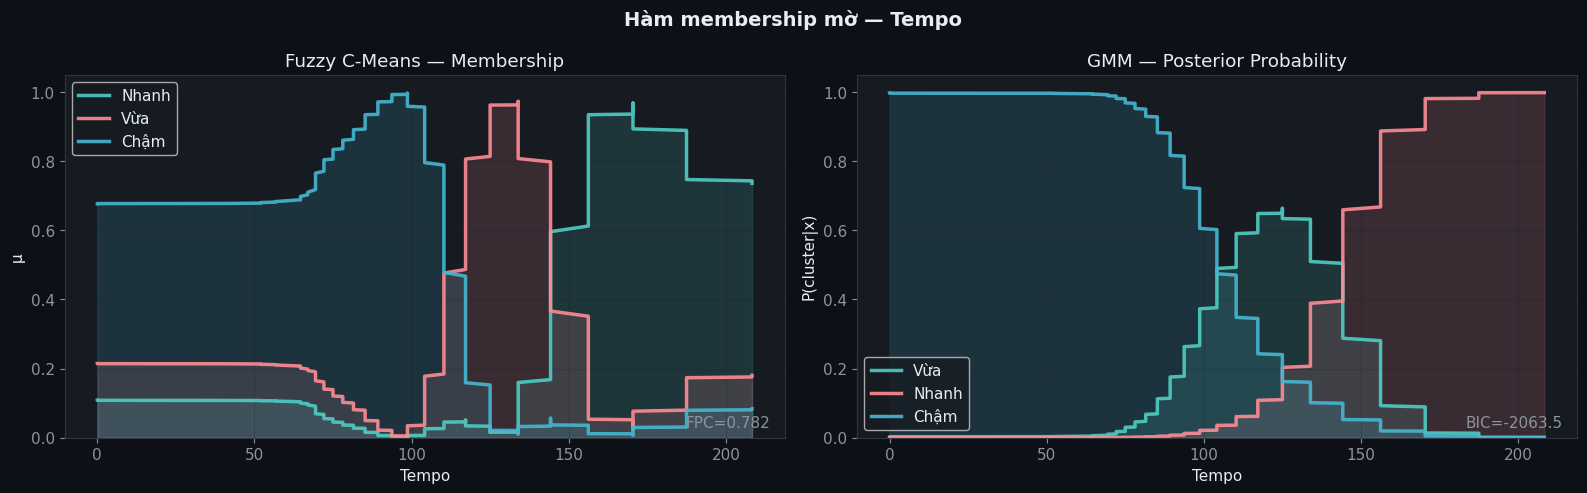

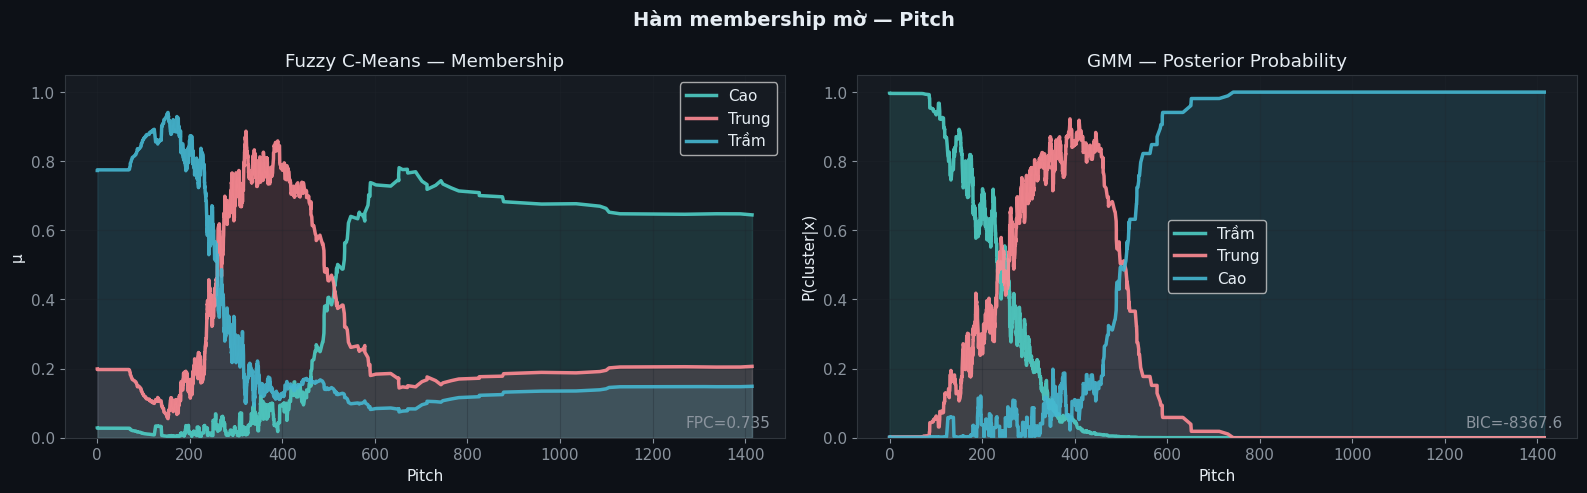

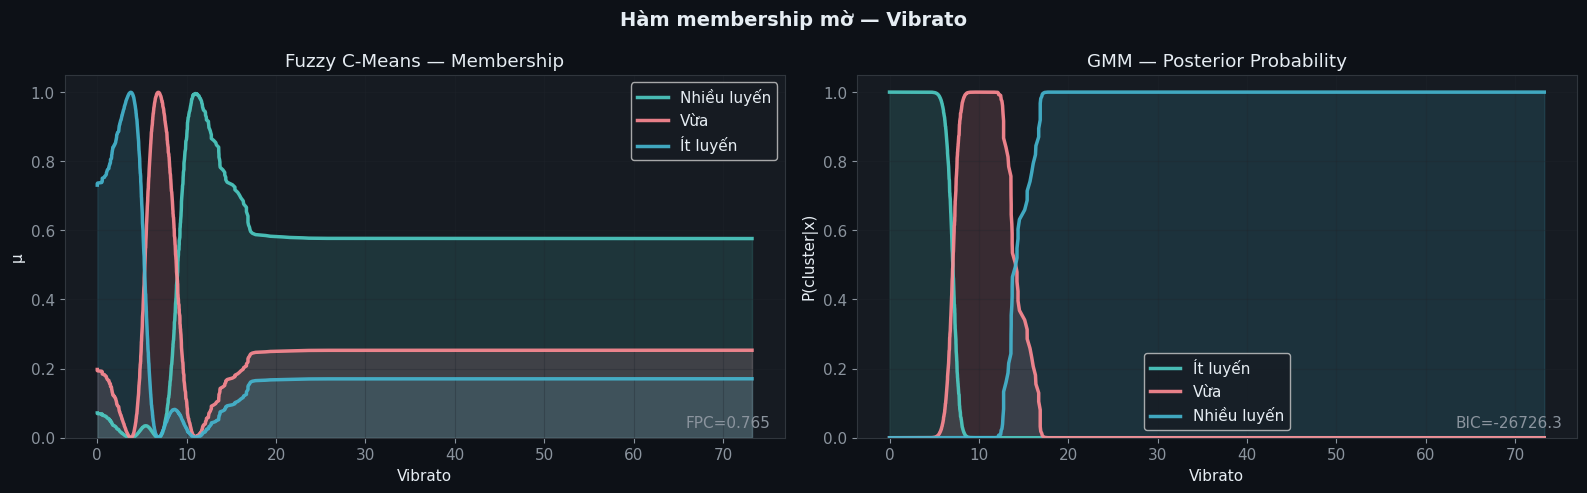

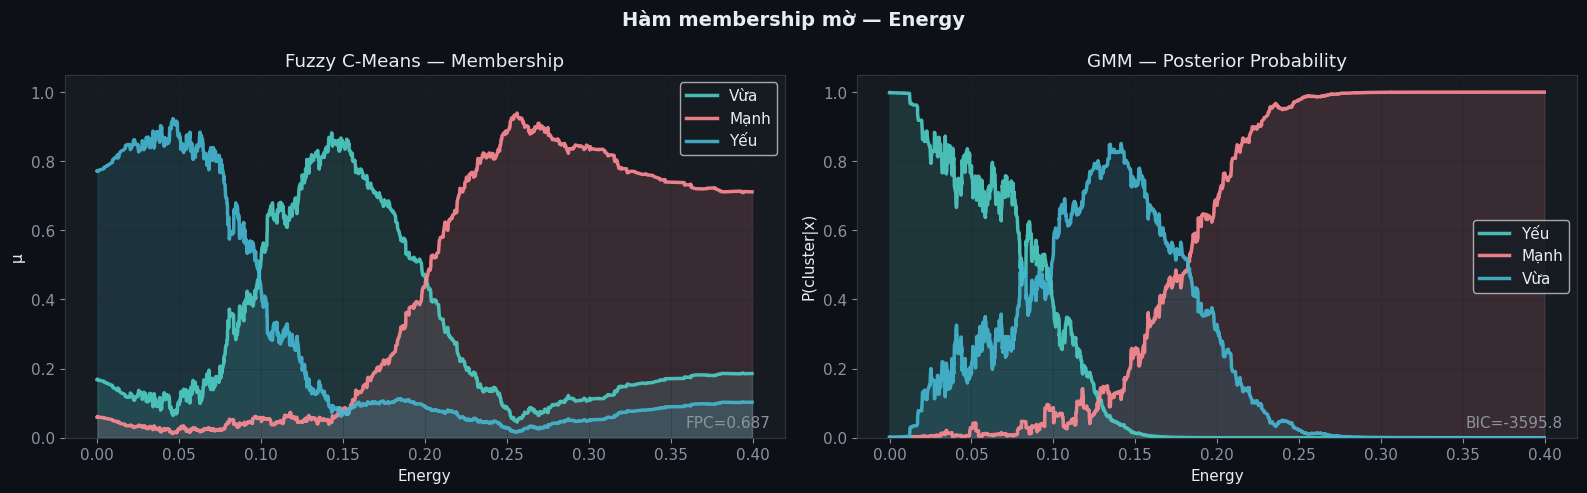

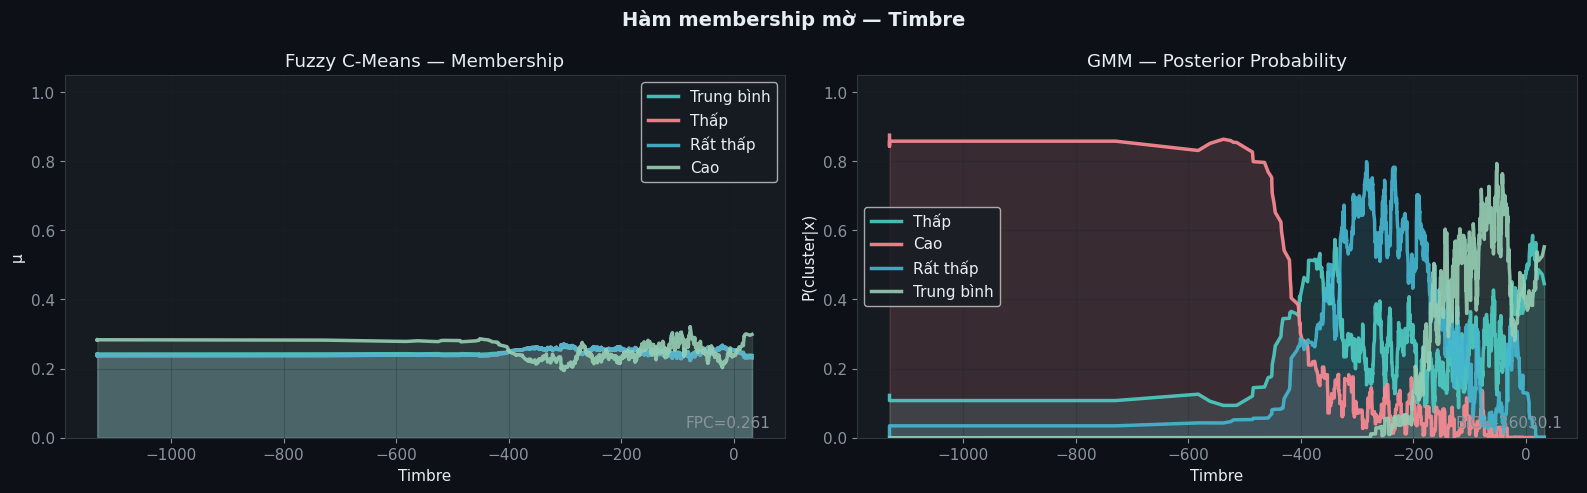

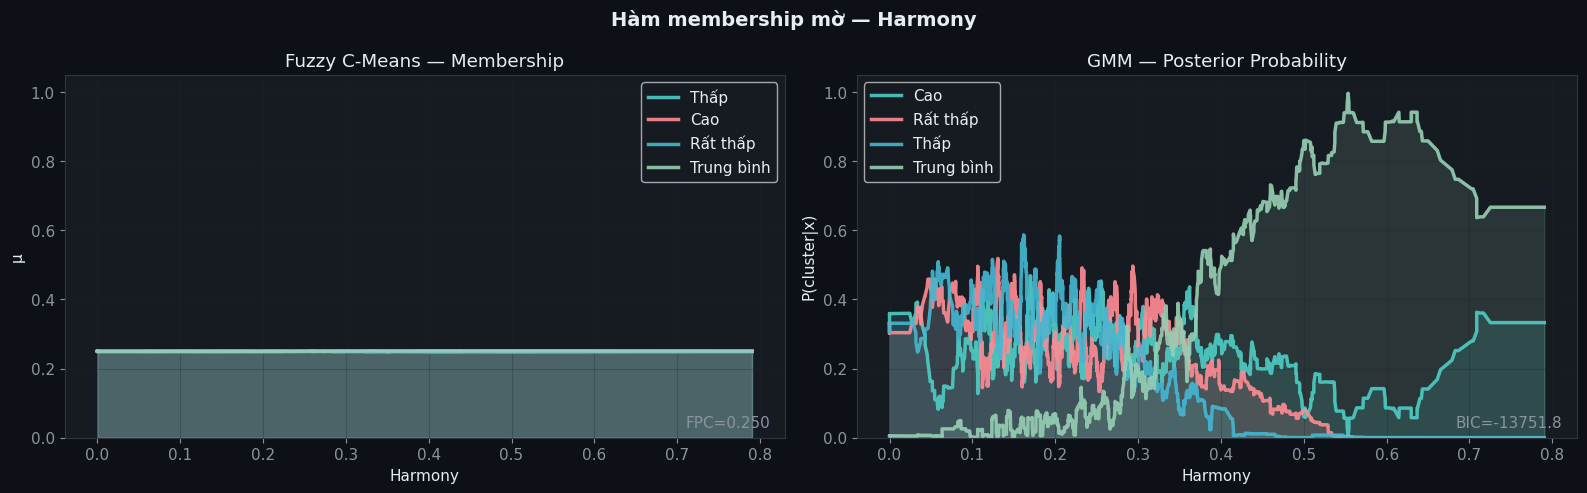

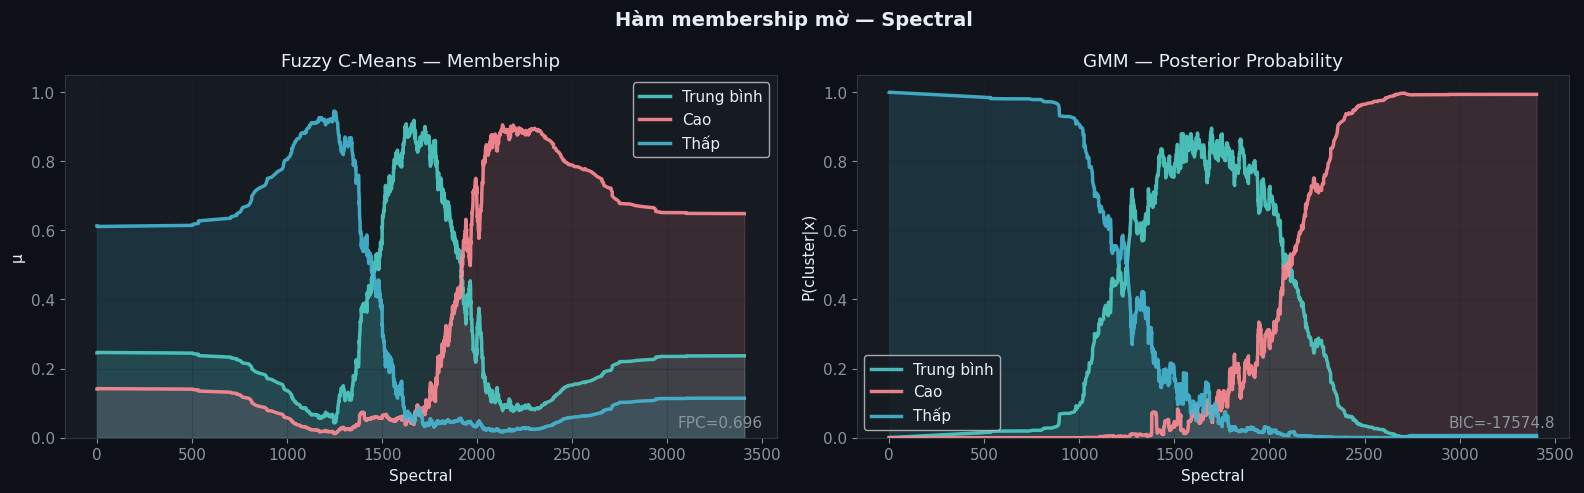

In [18]:
# Vẽ biểu đồ hàm liên thuộc mờ (Membership Functions) cho 7 trục đặc trưng (27 mức độ)
from scipy.ndimage import uniform_filter1d

PALETTE_3 = ['#4ECDC4', '#FFEAA7', '#FF6B6B']
PALETTE_5 = ['#45B7D1', '#4ECDC4', '#96CEB4', '#FFEAA7', '#FF6B6B']

def plot_membership(ax_name, fcm, gmm_r, fvals):
    fvals = np.nan_to_num(fvals)
    k = fcm['k']
    names = MUSIC_L[ax_name]
    colors = PALETTE_5 if k == 5 else PALETTE_3
    
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 5.5), facecolor='#0d1117')
    fig.suptitle(f'Hàm Liên Thuộc Mờ (Membership Functions) — Trục {ax_name} ({k} mức độ)',
                 fontsize=14, fontweight='bold', color='#e6edf3', y=0.98)
    
    sidx = np.argsort(fvals)
    xs = fvals[sidx]
    smooth_w = max(5, len(sidx) // 40)

    # 1. Fuzzy C-Means (FCM)
    if fcm:
        for i in range(k):
            c_orig = fcm['sorted_idx'][i]
            label_name = names[i]
            us = uniform_filter1d(fcm['membership'][c_orig, sidx], size=smooth_w)
            a1.plot(xs, us, color=colors[i], lw=2.5, label=label_name, alpha=0.95)
            a1.fill_between(xs, us, alpha=0.18, color=colors[i])
        a1.set_title(f'Fuzzy C-Means (FCM) — {k} Tập Mờ', fontsize=12, fontweight='bold', pad=10)
        a1.set_ylim(-0.02, 1.05)
        a1.set_xlabel(f'Giá trị đại diện {ax_name}')
        a1.set_ylabel('Độ thuộc (μ)')
        a1.legend(loc='upper right', framealpha=0.6, fontsize=9)
        a1.grid(alpha=0.25, linestyle='--')
        a1.text(0.02, 0.95, f'FPC = {fcm["fpc"]:.3f}', transform=a1.transAxes, ha='left', va='top',
                color='#58a6ff', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#161b22', edgecolor='#30363d'))

    # 2. Gaussian Mixture Model (GMM)
    if gmm_r:
        for i in range(k):
            c_orig = gmm_r['sorted_idx'][i]
            label_name = names[i]
            ps = uniform_filter1d(gmm_r['probs'][sidx, c_orig], size=smooth_w)
            a2.plot(xs, ps, color=colors[i], lw=2.5, label=label_name, alpha=0.95)
            a2.fill_between(xs, ps, alpha=0.18, color=colors[i])
        a2.set_title('Gaussian Mixture Model (GMM) — Xác Suất Hậu Nghiệm', fontsize=12, fontweight='bold', pad=10)
        a2.set_ylim(-0.02, 1.05)
        a2.set_xlabel(f'Giá trị đại diện {ax_name}')
        a2.set_ylabel('Xác suất P(cụm | x)')
        a2.legend(loc='upper right', framealpha=0.6, fontsize=9)
        a2.grid(alpha=0.25, linestyle='--')
        a2.text(0.02, 0.95, f'BIC = {gmm_r["bic"]:.1f}', transform=a2.transAxes, ha='left', va='top',
                color='#58a6ff', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#161b22', edgecolor='#30363d'))

    plt.tight_layout()
    plt.savefig(f'./data/membership_{ax_name.lower()}.png', dpi=150,
                bbox_inches='tight', facecolor='#0d1117')
    plt.show()

for ax_name in FUZZY_AXES:
    vf = [f for f in FUZZY_AXES[ax_name] if f in feat_col_idx]
    if vf and vf[0] in df.columns:
        plot_membership(ax_name, fcm_res.get(ax_name),
                        gmm_res.get(ax_name), df[vf[0]].fillna(0).values)


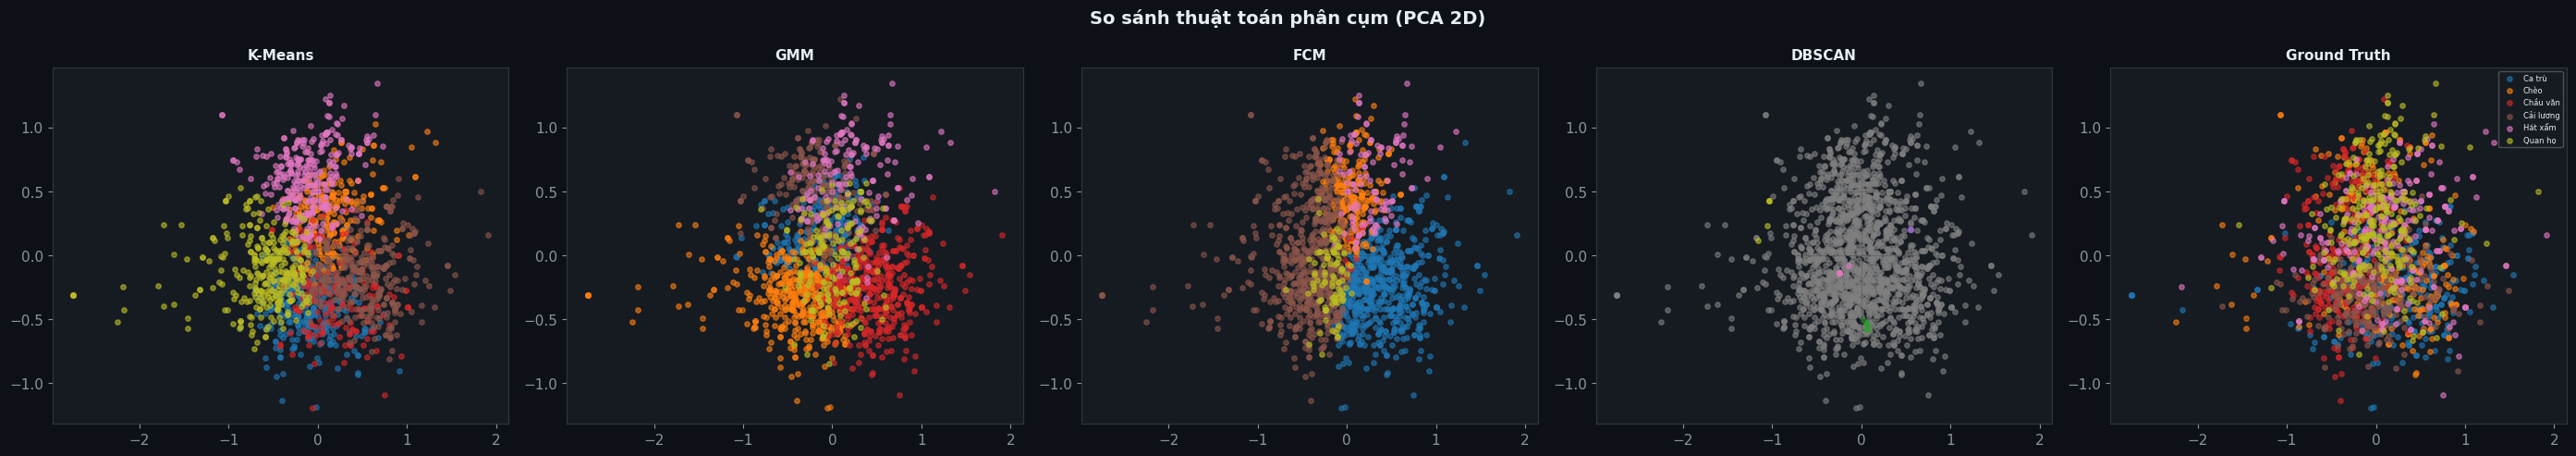

Saved: ./data/07_clustering_comparison.png


In [19]:
# So sánh 4 thuật toán + Ground Truth trên PCA 2D
pca2  = PCA(n_components=2, random_state=42)
X2d   = pca2.fit_transform(np.nan_to_num(Xs))
K     = len(df['label'].unique())
le    = LabelEncoder()
ytrue = le.fit_transform(df['label'].values)

km_lbl  = KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(np.nan_to_num(Xs))
gmm_g   = GaussianMixture(n_components=K, random_state=42, n_init=5).fit(np.nan_to_num(Xs))
gmm_lbl = gmm_g.predict(np.nan_to_num(Xs))
_, ug, _, _, _, _, _ = cmeans(np.nan_to_num(Xs).T, c=K, m=2.0, error=0.005, maxiter=500, seed=42)
fcm_lbl = np.argmax(ug, axis=0)
db_lbl  = DBSCAN(eps=0.8, min_samples=5).fit_predict(np.nan_to_num(Xs))

all_algos = [('K-Means',km_lbl),('GMM',gmm_lbl),('FCM',fcm_lbl),
             ('DBSCAN',db_lbl),('Ground Truth',ytrue)]
cmap_tab = plt.cm.get_cmap('tab10')

fig, axs = plt.subplots(1, 5, figsize=(28, 5), facecolor='#0d1117')
fig.suptitle('So sánh thuật toán phân cụm (PCA 2D)', fontsize=14, fontweight='bold', color='#e6edf3')

for ax, (name, lbls) in zip(axs, all_algos):
    ul = np.unique(lbls)
    for i, lbl in enumerate(ul):
        mask = lbls==lbl
        c    = 'gray' if lbl==-1 else cmap_tab(i/max(len(ul),1))
        nm   = le.classes_[lbl] if name=='Ground Truth' and lbl>=0 else str(lbl)
        ax.scatter(X2d[mask,0],X2d[mask,1],c=[c],s=15,alpha=0.6,
                   label=nm if name=='Ground Truth' else None)
    ax.set_title(name,fontsize=11,color='#e6edf3',fontweight='bold'); ax.grid(alpha=0.2)
    if name=='Ground Truth': ax.legend(fontsize=6,framealpha=0.3)

plt.tight_layout()
plt.savefig('./data/07_clustering_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/07_clustering_comparison.png')

## Bước 5: Bảng Tổng Hợp Hồ Sơ Mờ

In [20]:
# Tổng hợp hồ sơ mờ theo thể loại
genre_profile = {}
for genre in df['label'].unique():
    mask = df['label'].values == genre
    gp = {}
    for ax_name, fcm in fcm_res.items():
        u   = fcm['membership']
        u_g = u[:, mask].mean(axis=1)
        dom = np.argmax(u_g)
        gp[ax_name] = dict(
            dominant=fcm['names'].get(dom,f'Cụm {dom}'),
            score=float(u_g[dom]),
            all={fcm['names'].get(c,f'Cụm {c}'): round(float(u_g[c]),3) for c in range(fcm['k'])}
        )
    genre_profile[genre] = gp

print('='*95)
print(f'{"Thể loại":25s}', end='')
for ax in fcm_res: print(f'  {ax:12s}', end='')
print()
print('-'*95)
for genre, gp in genre_profile.items():
    print(f'{genre:25s}', end='')
    for ax in fcm_res:
        if ax in gp: print(f'  {gp[ax]["dominant"]:7s}({gp[ax]["score"]:.2f})', end='')
        else:        print(f'  {"N/A":12s}', end='')
    print()
print('='*95)

Thể loại                   Tempo         Pitch         Vibrato       Energy        Timbre        Harmony       Spectral    
-----------------------------------------------------------------------------------------------
Cải lương                  Chậm   (0.36)  Trầm   (0.50)  Vừa    (0.47)  Yếu    (0.66)  Cao    (0.30)  Thấp   (0.25)  Trung bình(0.41)
Quan họ                    Vừa    (0.80)  Trung  (0.56)  Vừa    (0.47)  Mạnh   (0.42)  Cao    (0.29)  Rất thấp(0.25)  Trung bình(0.55)
Chầu văn                   Vừa    (0.38)  Trầm   (0.76)  Ít luyến(0.70)  Vừa    (0.49)  Cao    (0.28)  Cao    (0.25)  Trung bình(0.43)
Chèo                       Chậm   (0.41)  Trung  (0.57)  Vừa    (0.43)  Yếu    (0.49)  Rất thấp(0.27)  Thấp   (0.25)  Trung bình(0.57)
Ca trù                     Vừa    (0.47)  Trung  (0.53)  Vừa    (0.52)  Yếu    (0.61)  Rất thấp(0.27)  Thấp   (0.25)  Trung bình(0.39)
Hát xẩm                    Vừa    (0.35)  Trầm   (0.49)  Vừa    (0.48)  Mạnh   (0.41)  Rất thấp(0.27)  Tru

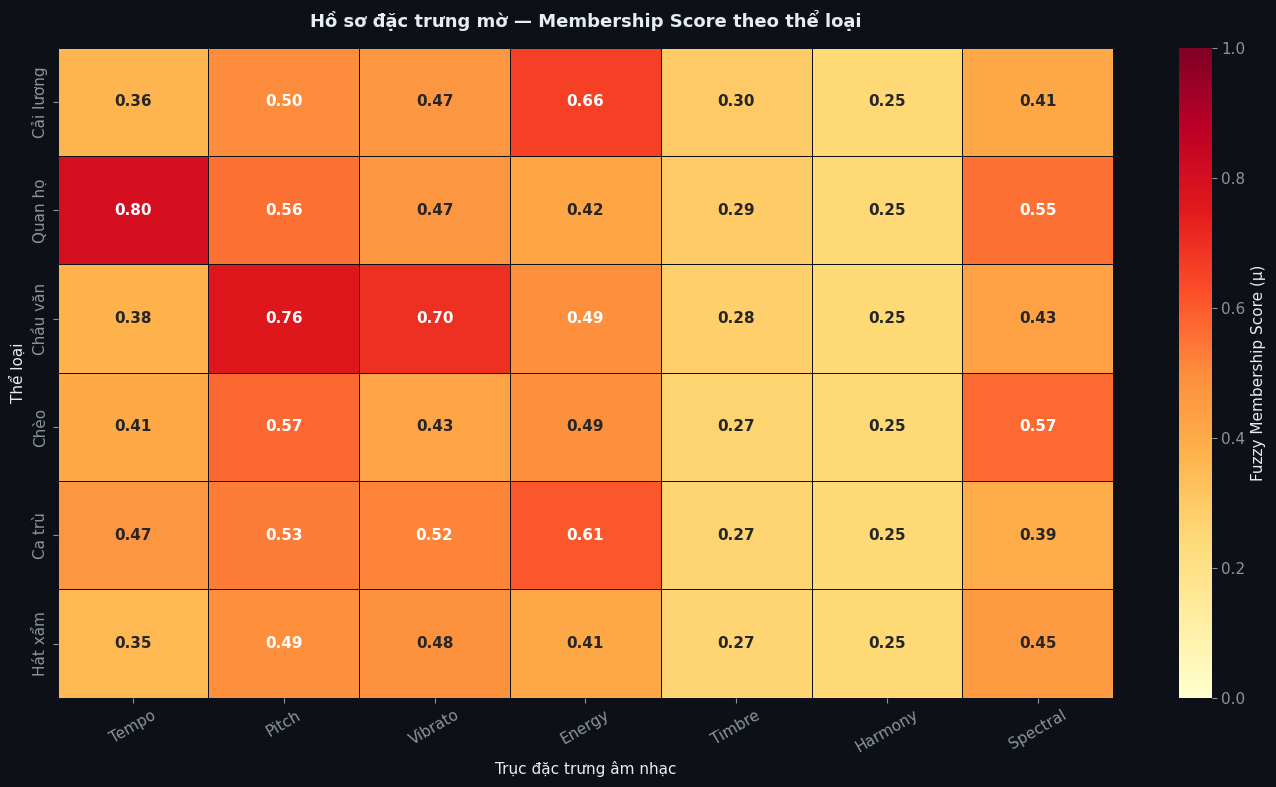

Saved: ./data/08_fuzzy_profile_heatmap.png


In [21]:
# Heatmap hồ sơ mờ
rows = [{'Thể loại': genre, **{ax: info['score'] for ax, info in gp.items()}}
        for genre, gp in genre_profile.items()]
df_hm = pd.DataFrame(rows).set_index('Thể loại')

fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0d1117')
sns.heatmap(df_hm, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            ax=ax, linewidths=0.5, linecolor='#0d1117',
            annot_kws={'size':11,'weight':'bold'},
            cbar_kws={'label':'Fuzzy Membership Score (μ)'})
ax.set_title('Hồ sơ đặc trưng mờ — Membership Score theo thể loại',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Trục đặc trưng âm nhạc', fontsize=11)
ax.set_ylabel('Thể loại', fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('./data/08_fuzzy_profile_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/08_fuzzy_profile_heatmap.png')

In [22]:
# Lưu tất cả kết quả
out = {g: {'name':g,'axes':{ax:{'dominant':info['dominant'],
            'score':round(info['score'],4),'all':info['all']}
            for ax,info in gp.items()}}
       for g, gp in genre_profile.items()}

with open('./data/fuzzy_profiles.json','w',encoding='utf-8') as f:
    json.dump(out, f, ensure_ascii=False, indent=2)

fcm_save = {k:{kk:vv for kk,vv in v.items()} for k,v in fcm_res.items()}
with open('./data/fcm_results.pkl','wb') as f: pickle.dump(fcm_save,f)
with open('./data/gmm_results.pkl','wb') as f: pickle.dump(gmm_res,f)

print('Đã lưu:')
print('  ./data/features_all.csv')
print('  ./data/fuzzy_profiles.json')
print('  ./data/fcm_results.pkl')
print('  ./data/gmm_results.pkl')
print()
for p in sorted(Path('./data').glob('*.png')):
    print(f'  {p.name}')
print('\n🎉 HOÀN THÀNH!')

Đã lưu:
  ./data/features_all.csv
  ./data/fuzzy_profiles.json
  ./data/fcm_results.pkl
  ./data/gmm_results.pkl

  01_genre_distribution.png
  02_violin_comparison.png
  03_radar_chart.png
  04_pca_tsne.png
  05_correlation.png
  06_optimal_k.png
  07_clustering_comparison.png
  08_fuzzy_profile_heatmap.png
  membership_energy.png
  membership_harmony.png
  membership_pitch.png
  membership_spectral.png
  membership_tempo.png
  membership_timbre.png
  membership_vibrato.png
  viz_Ca_trù.png
  viz_Chèo.png
  viz_Chầu_văn.png
  viz_Cải_lương.png
  viz_Hát_xẩm.png
  viz_Quan_họ.png

🎉 HOÀN THÀNH!
